In [1]:
# === SETUP: Run this first! ===
import os
import sys

# Change to project root and add to Python path
notebook_dir = os.getcwd()
project_root = os.path.dirname(notebook_dir)  # Goes up one level from 'notebooks/'
os.chdir(project_root)
sys.path.insert(0, project_root)

print(f"Project root: {project_root}")
print(f"tsnn module path: {os.path.join(project_root, 'tsnn')}")

Project root: /Users/gremy/Code/TSNN-1
tsnn module path: /Users/gremy/Code/TSNN-1/tsnn


In [2]:
%load_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.linear_model import LassoCV, RidgeCV, LinearRegression
import torch
from torch.utils.data import Dataset, random_split
from torch.utils.data import DataLoader
import importlib
import sys
sys.path.append('/Users/cyrilgarcia/notebooks/tsnn/')

import tsnn

from tsnn.generators import generators
from tsnn import tstorch
from tsnn.benchmarks import benchmark_comparison, ml_benchmarks, torch_benchmarks
from tsnn import utils
from tsnn.tstorch import transformers
import torch.nn.functional as F
import math
from typing import Optional

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.neural_network import MLPRegressor

from torch import nn
from tqdm import tqdm
device = 'mps'


plt.style.use('ggplot')

In [3]:
# This is the new version of the notebook to make all the figures for the paper.

In [4]:
from tsnn.tstorch import models
from tsnn.benchmarks import torch_benchmarks
from tsnn.benchmarks.torch_benchmarks import MSELossWithL1Sparsity

# Defining the data parameters

In [5]:
# The first thing that we want to do is define all of parameters of the data we will be testing on.

For now we will be working with the following effects:
- Simple linear dependency
- TS shift with lags chosen randomly for each feature, but constant accros stocks
- CS shift, with lags chosen randomly for each stock and each feature
- TS-CS shift: combination of the two lags above
- Conditioning of one feature by another

We will fix the following global correlation levels: $\rho$ = 1,2,5,10,20,50. The first and last might not be too meaningful.

Next let's fix the size of the data that we want to test. We will always work with $T=4000$ points, and use $2500$ for training, $1500$ for testing. For the other dimensions:
- Default 1: n_ts = 10, n_rolling = 10, n_f = 20. This gives $\gamma = 0.8$.
- Default 2: n_ts = 10, n_rolling = 10, n_f = 5. This gives $\gamma = 0.2$.

Could also add two extra cases to test larger n_rolling or n_ts:
- Long TS: n_ts = 10, n_rolling = 40, n_f = 5. This gives $\gamma = 0.8$.
- Long CS: n_ts = 40, n_rolling = 10, n_f = 5. This gives $\gamma = 0.8$.

Can also run an experiment varying jointly $\rho$ and $\gamma$ at a fixed theo correl level.

Next we need to compute a $\rho$ per feature. In the case where n_f=5, we will simply take $\frac{\rho}{\sqrt{5}}$ per feature. In the case n_f=20, we will take $\frac{\rho}{\sqrt{10}}$ for half of the features and $0$ for the half.

In [6]:
# Some basic functions.

In [7]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool

In [8]:
def get_ols_corr(N_fea, T_train, rho, oos=True):
    ratio = N_fea/T_train
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)


In [9]:
def keep_topk_per_row3(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [10]:
def keep_by_max_value2(x, frac=0.2):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out


# Running models by hand

In [11]:
# Let's put here the code to run models with the original data generations

In [12]:
# Main parameters

T=4000
n_rolling = 10
n_f = 5
n_ts = 40

rho = 0.2
effect = 'd_cs'


In [13]:
# Build data

if n_f < 10:
    pct_zero_corr = 0
else:
    pct_zero_corr = 0.5

c = rho/np.sqrt((1-pct_zero_corr)*n_f)

arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
            'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
            'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
            'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
            }

z = generators.Generator(T, n_ts, n_f)

z.generate_dataset(
        pct_zero_corr=arg_list[effect]['pct_zero_corr'],
        split_conditional=arg_list[effect]['split_conditional'],
        split_shift=arg_list[effect]['split_shift'],
        split_seasonal=arg_list[effect]['split_seasonal'],
        split_cs=arg_list[effect]['split_cs'],
        split_cs_shift=arg_list[effect]['split_cs_shift'],
        random_ts_shift=n_rolling-1,
        low_corr=c,
        high_corr=c,
        shuffle_cs=True
    )

z.get_dataloader()


In [14]:
# Define a list of models

embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)


models_torch = {
    # 'full_attention_TCTC': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
    #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
    # 'top3_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
    #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
    'max2_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
        dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_by_max_value2, roll_y=True, embeddings=embeddings_dict[effect],
    ).to(device),
   
}


Running correl level: 0.2
Running model: max2_sparse_attention_TCTC


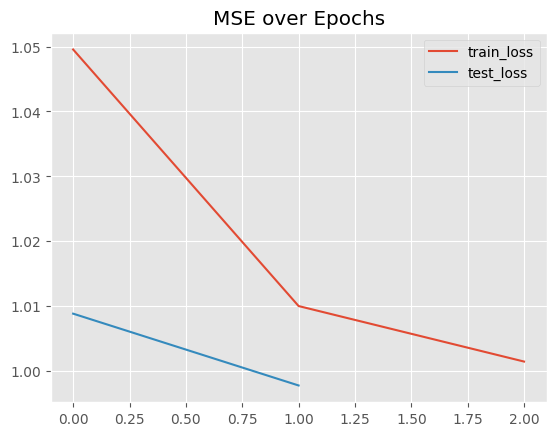

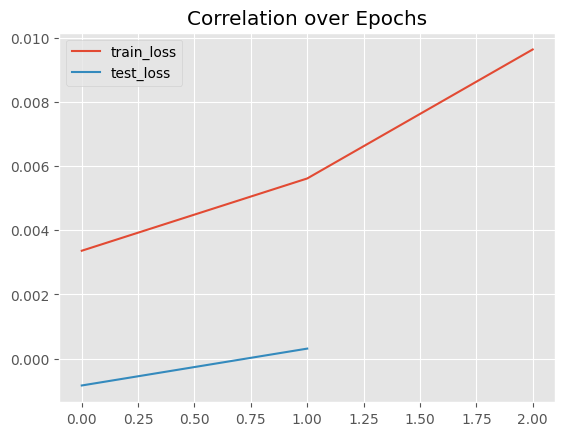

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


KeyError: 'max2_sparse_attention_TCTC'

In [15]:
# Code to run the model with the parameters above.

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    print("Running model:", k)
    models_torch[k].fit(z.train, test=z.test, epochs=40, plot=True, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

for k in models_torch:

    train_corr = corr_train.loc[k, "optimal"]
    test_corr  = corr_test.loc[k, "optimal"]

    res_train.append({
        "rho": rho,
        "model": k,
        "train_corr_optimal": train_corr
    })
    res_test.append({
        "rho": rho,
        "model": k,
        "test_corr_optimal": test_corr
    })


res_train.append({
        "rho": rho,
        "model": "theo_correl",
        "train_corr_optimal": theo_correl_is
    })
res_test.append({
        "rho": rho,
        "model": "theo_correl",
        "test_corr_optimal": theo_correl_oos
    })


res_train = pd.DataFrame(res_train)
res_test  = pd.DataFrame(res_test)

res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

In [16]:
res_train

[{'rho': 0.2,
  'model': 'full_attention_TCTC',
  'train_corr_optimal': np.float64(0.2550130697485531)}]

In [17]:
res_test

[{'rho': 0.2,
  'model': 'full_attention_TCTC',
  'test_corr_optimal': np.float64(0.21916392919173533)}]

## Visualizing attention matrices

In [22]:
pd.DataFrame(np.array(models_torch['full_attention_CC'].model.blocks[0].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_90098/197335040.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['full_attention_CC'].model.blocks[0].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,0.084,0.104,0.074,0.129,0.081,0.071,0.094,0.124,0.133,0.105
1,0.090,0.086,0.098,0.116,0.103,0.084,0.070,0.113,0.132,0.110
2,0.116,0.096,0.081,0.090,0.083,0.086,0.100,0.124,0.138,0.088
3,0.116,0.081,0.088,0.089,0.077,0.094,0.123,0.120,0.098,0.113
4,0.069,0.097,0.090,0.157,0.064,0.151,0.086,0.082,0.078,0.126
5,0.072,0.088,0.097,0.137,0.070,0.108,0.076,0.096,0.099,0.156
6,0.163,0.070,0.094,0.120,0.071,0.066,0.099,0.087,0.137,0.092
7,0.080,0.090,0.100,0.160,0.074,0.082,0.082,0.106,0.103,0.123
8,0.104,0.101,0.103,0.113,0.060,0.115,0.078,0.099,0.090,0.139
9,0.122,0.113,0.105,0.096,0.088,0.086,0.097,0.091,0.114,0.089


In [23]:
pd.DataFrame(np.array(models_torch['full_attention_CC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_90098/4285153544.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['full_attention_CC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,0.121,0.075,0.131,0.116,0.098,0.067,0.168,0.065,0.086,0.073
1,0.137,0.071,0.139,0.099,0.120,0.069,0.112,0.080,0.085,0.087
2,0.146,0.059,0.114,0.098,0.121,0.070,0.099,0.091,0.120,0.081
3,0.152,0.052,0.112,0.081,0.105,0.078,0.145,0.081,0.097,0.097
4,0.115,0.094,0.099,0.104,0.108,0.095,0.120,0.090,0.086,0.088
5,0.111,0.060,0.107,0.088,0.129,0.071,0.112,0.098,0.111,0.113
6,0.091,0.072,0.087,0.109,0.128,0.086,0.101,0.095,0.118,0.114
7,0.111,0.085,0.133,0.076,0.101,0.080,0.126,0.091,0.068,0.129
8,0.103,0.095,0.113,0.112,0.080,0.087,0.119,0.072,0.079,0.139
9,0.110,0.071,0.089,0.093,0.108,0.084,0.119,0.092,0.128,0.107


In [24]:
pd.DataFrame(np.array(models_torch['top3_sparse_attention_CC'].model.blocks[0].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_90098/2163146771.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['top3_sparse_attention_CC'].model.blocks[0].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,0.050,0.120,0.181,0.045,0.056,0.074,0.106,0.107,0.160,0.102
1,0.111,0.009,0.143,0.124,0.165,0.102,0.147,0.021,0.082,0.096
2,0.088,0.115,0.190,0.054,0.099,0.103,0.089,0.067,0.085,0.109
3,0.065,0.110,0.170,0.114,0.112,0.052,0.109,0.065,0.124,0.078
4,0.150,0.041,0.126,0.118,0.099,0.113,0.114,0.134,0.107,0.000
5,0.022,0.067,0.104,0.014,0.188,0.179,0.020,0.117,0.149,0.141
6,0.093,0.097,0.164,0.074,0.039,0.106,0.084,0.083,0.224,0.037
7,0.102,0.112,0.156,0.121,0.117,0.110,0.034,0.142,0.083,0.023
8,0.053,0.047,0.225,0.062,0.116,0.154,0.073,0.048,0.120,0.100
9,0.110,0.135,0.099,0.091,0.148,0.090,0.056,0.092,0.118,0.061


In [25]:
pd.DataFrame(np.array(models_torch['top3_sparse_attention_CC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_90098/2559520672.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['top3_sparse_attention_CC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,0.089,0.057,0.103,0.123,0.122,0.060,0.066,0.163,0.189,0.028
1,0.195,0.033,0.088,0.134,0.170,0.019,0.128,0.098,0.079,0.058
2,0.089,0.096,0.059,0.114,0.178,0.084,0.097,0.136,0.061,0.086
3,0.179,0.081,0.095,0.098,0.147,0.049,0.043,0.150,0.087,0.072
4,0.147,0.089,0.093,0.123,0.151,0.097,0.073,0.111,0.103,0.014
5,0.158,0.047,0.122,0.105,0.117,0.048,0.101,0.118,0.092,0.091
6,0.140,0.049,0.139,0.142,0.054,0.061,0.080,0.148,0.083,0.104
7,0.169,0.063,0.101,0.139,0.061,0.060,0.100,0.076,0.147,0.084
8,0.121,0.054,0.152,0.091,0.080,0.076,0.114,0.084,0.095,0.133
9,0.147,0.064,0.151,0.201,0.143,0.025,0.101,0.060,0.045,0.062


# Running models by hand on the new data

In [11]:
# Lets put here the code to run some models by hand using the new generate data function

In [17]:
# Parameters

T=4000
n_rolling = 10
n_f = 20
n_ts = 10

rho = 0.05

# The possible effects are: lin, TS_shift, CS_shift, TSCS_shift, fea_cond, TS_cond, CS_cond

#list_effects1 = ["lin", "TS_shift", "CS_shift", "TSCS_shift", "fea_cond", "TS_cond", "CS_cond"]*2
list_effects1 = ["TS_shift"]*20

print(list_effects1)

['TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift', 'TS_shift']


In [18]:
# Define the data:

z = generators.Generator(T, n_ts, n_f)

z.generate_dataset_gr_simple(
        global_corr=rho, 
        correl_split_by_fea=None, 
        list_type_effects=list_effects1,
        list_type_interaction=["cond"], 
        random_ts_shift=n_rolling,
    )

z.get_dataloader()


In [19]:
# Define the models

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)


models_torch = {
    'full_attention_TC': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TTTT', nhead=16,
        dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings="both",
    ).to(device),

}

Running correl level: 0.05
Running model: full_attention_TC


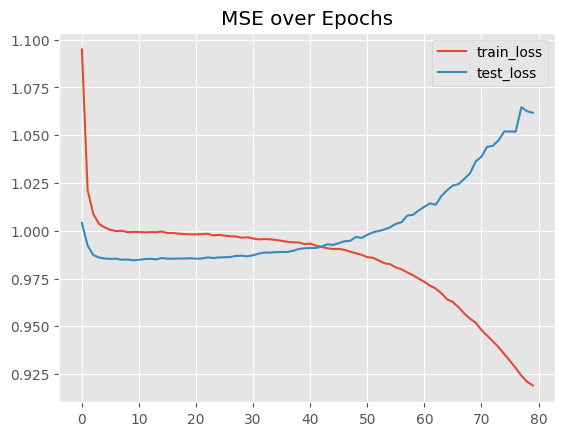

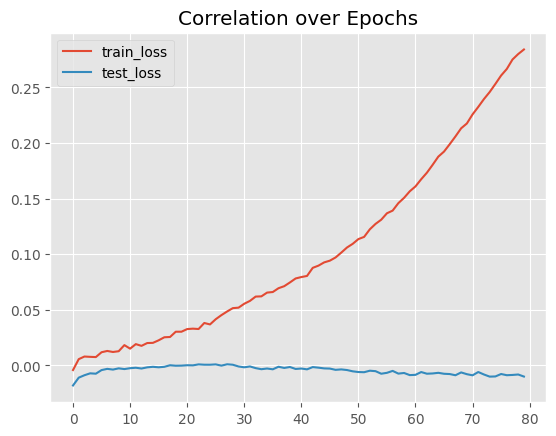

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [20]:
# Code to run the model with the parameters above.

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    print("Running model:", k)
    models_torch[k].fit(z.train, test=z.test, epochs=80, plot=True, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

for k in models_torch:
    train_corr = corr_train.loc[k, "optimal"]
    test_corr  = corr_test.loc[k, "optimal"]

    res_train.append({
        "rho": rho,
        "model": k,
        "train_corr_optimal": train_corr
    })
    res_test.append({
        "rho": rho,
        "model": k,
        "test_corr_optimal": test_corr
    })


res_train.append({
        "rho": rho,
        "model": "theo_correl",
        "train_corr_optimal": theo_correl_is
    })
res_test.append({
        "rho": rho,
        "model": "theo_correl",
        "test_corr_optimal": theo_correl_oos
    })


res_train = pd.DataFrame(res_train)
res_test  = pd.DataFrame(res_test)

res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

In [21]:
res_train

model,full_attention_TC,theo_correl
rho,,
0.05,0.032077,0.055884


In [22]:
res_test

model,full_attention_TC,theo_correl
rho,,
0.05,0.009404,0.025023


# Running all the models on all the effects

In [11]:
# Next in the section we write the code to run all of our models on all of the effects.

In [12]:
# Function to run all of the models.

In [50]:
def run_models1(rhos, effect, T=4000, n_ts=10, n_f=20, n_rolling=10):

    embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)

    if n_f < 10:
        pct_zero_corr = 0
    else:
        pct_zero_corr = 0.5

    cs = [rho/np.sqrt((1-pct_zero_corr)*n_f) for rho in rhos]

    arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
                'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
                'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
                'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
               }
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []
    for (i,c) in enumerate(cs):
        print("Running correl level:", rhos[i])
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rhos[i], oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rhos[i], oos=True)

        z.generate_dataset(
                pct_zero_corr=arg_list[effect]['pct_zero_corr'],
                split_conditional=arg_list[effect]['split_conditional'],
                split_shift=arg_list[effect]['split_shift'],
                split_seasonal=arg_list[effect]['split_seasonal'],
                split_cs=arg_list[effect]['split_cs'],
                split_cs_shift=arg_list[effect]['split_cs_shift'],
                random_ts_shift=n_rolling-1,
                low_corr=c,
                high_corr=c,
                shuffle_cs=True
            )

        z.get_dataloader()


        models_torch = {
        'full_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
        ).to(device),
        'top3_sparse_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict[effect],
        ).to(device),
        'full_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
        ).to(device),
        'top3_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict[effect],
        ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=n_rolling, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test


## Testing on one effect

In [14]:
tfull_shift_train, tfull_shift_test = run_models1([0.02, 0.05, 0.1, 0.2, 0.5], 'd_shift')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [15]:
display(tfull_shift_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_shift_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.025,0.054,0.142,0.256,0.583
full_attention_TCTC,0.024,0.061,0.120,0.214,0.494
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.022,0.039,0.107,0.167,0.534
full_attention_TCTC,0.017,0.032,0.073,0.104,0.420
theo_correl,0.010,0.025,0.050,0.102,0.277


## Running on all effects

In [ ]:
#all_effects1_train_dic = {}
#all_effects1_test_dic = {}

In [52]:
for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:
    print("Running_effect:", effect)
    out_train1, out_test1 = run_models1([0.02, 0.05, 0.1, 0.2, 0.5], effect)
    all_effects1_train_dic[effect] = out_train1
    all_effects1_test_dic[effect] = out_test1


Running_effect: d_lin
Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


...

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [55]:
all_effects1_train_dic.keys()

dict_keys(['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all'])

In [56]:
for effect in ['d_lin', 'd_cond', 'd_shift', 'd_cs', 'd_cs_shift', 'd_all']:
    print(effect)
    display(all_effects1_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(all_effects1_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

d_lin


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.051,0.147,0.293,0.531,0.837
full_attention_TCTC,0.042,0.099,0.232,0.471,0.817
theo_correl,0.022,0.056,0.112,0.222,0.542
top3_sparse_attention_TC,0.087,0.199,0.491,0.750,0.926
top3_sparse_attention_TCTC,0.057,0.161,0.462,0.649,0.884


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.053,0.156,0.278,0.545,0.841
full_attention_TCTC,0.049,0.103,0.239,0.507,0.831
theo_correl,0.010,0.025,0.050,0.102,0.277
top3_sparse_attention_TC,0.087,0.200,0.505,0.759,0.927
top3_sparse_attention_TCTC,0.072,0.164,0.459,0.666,0.889


d_cond


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.033,0.136,0.173,0.380,0.685
full_attention_TCTC,0.045,0.133,0.196,0.364,0.633
theo_correl,0.022,0.056,0.112,0.222,0.542
top3_sparse_attention_TC,0.045,0.238,0.286,0.488,0.750
top3_sparse_attention_TCTC,0.064,0.182,0.263,0.456,0.719


...

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.007,0.006,0.018,0.016,0.058
full_attention_TCTC,0.007,-0.002,0.009,0.019,0.117
theo_correl,0.022,0.056,0.112,0.222,0.542
top3_sparse_attention_TC,0.000,0.002,0.013,0.030,0.069
top3_sparse_attention_TCTC,0.006,0.012,0.018,0.050,0.106


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.005,-0.010,-0.010,-0.008,-0.009
full_attention_TCTC,-0.008,0.003,0.003,0.003,0.000
theo_correl,0.010,0.025,0.050,0.102,0.277
top3_sparse_attention_TC,-0.014,-0.002,-0.002,0.007,-0.002
top3_sparse_attention_TCTC,-0.014,0.007,-0.002,0.012,-0.008


d_all


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.058,0.088,0.279,0.340,0.658
full_attention_TCTC,0.112,0.131,0.156,0.359,0.654
theo_correl,0.022,0.056,0.112,0.222,0.542
top3_sparse_attention_TC,0.127,0.062,0.212,0.342,0.684
top3_sparse_attention_TCTC,0.033,0.097,0.266,0.361,0.660


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.059,0.067,0.259,0.292,0.627
full_attention_TCTC,0.105,0.122,0.123,0.326,0.622
theo_correl,0.010,0.025,0.050,0.102,0.277
top3_sparse_attention_TC,0.113,0.040,0.196,0.318,0.660
top3_sparse_attention_TCTC,0.015,0.093,0.241,0.329,0.627


## Adding the two new effects

In [ ]:
# Lets also add our two new effects to the dictionaries above.
# TO DO: need to complete this!!

# The possible effects are: lin, TS_shift, CS_shift, TSCS_shift, fea_cond, TS_cond, CS_cond


In [57]:
def run_models1_new_effects(rhos, effect, T=4000, n_ts=10, n_f=20, n_rolling=10):

    embeddings_dict_new = {'TS_cond': "T",  'CS_cond': "C"}

    list_effects1 = [effect]*n_f
    half_n_f = int(n_f/2)
    correl_split_by_fea1 = [1/np.sqrt(half_n_f)]*(half_n_f) + [0]*half_n_f 

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []

    for (i,rho) in enumerate(rhos):
        print("Running correl level:", rho)
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


        z.generate_dataset_gr_simple(
            global_corr=rho, 
            correl_split_by_fea=correl_split_by_fea1, 
            list_type_effects=list_effects1,
            list_type_interaction=["cond"], 
            random_ts_shift=n_rolling,
        )


        z.get_dataloader()


        models_torch = {
        'full_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'top3_sparse_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'full_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'top3_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=n_rolling, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test

In [ ]:
# twonew_effects1_train_dic = {}
# twonew_effects1_test_dic = {}

In [59]:
for effect in ["TS_cond", "CS_cond"]:
    print("Running_effect:", effect)
    out_train1, out_test1 = run_models1_new_effects([0.02, 0.05, 0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=20, n_rolling=10)
    twonew_effects1_train_dic[effect] = out_train1
    twonew_effects1_test_dic[effect] = out_test1

Running_effect: TS_cond
Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


...

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [60]:
for effect in ["TS_cond", "CS_cond"]:
    print(effect)
    display(twonew_effects1_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(twonew_effects1_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

TS_cond


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.004,0.019,0.022,0.019,0.034
full_attention_TCTC,-0.000,0.004,0.009,0.005,0.072
theo_correl,0.022,0.056,0.112,0.222,0.542
top3_sparse_attention_TC,-0.004,0.004,0.030,0.012,0.028
top3_sparse_attention_TCTC,0.009,0.005,0.016,0.033,0.033


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.013,-0.003,0.012,-0.002,0.004
full_attention_TCTC,-0.015,-0.015,0.004,-0.014,0.016
theo_correl,0.010,0.025,0.050,0.102,0.277
top3_sparse_attention_TC,-0.005,-0.014,-0.007,-0.004,0.007
top3_sparse_attention_TCTC,-0.006,-0.013,-0.000,0.008,0.000


CS_cond


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.009,0.017,0.039,0.103,0.256
full_attention_TCTC,0.012,0.021,0.062,0.108,0.196
theo_correl,0.022,0.056,0.112,0.222,0.542
top3_sparse_attention_TC,0.008,0.016,0.019,0.058,0.174
top3_sparse_attention_TCTC,0.008,0.019,0.051,0.088,0.140


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.005,0.005,-0.006,0.007,0.024
full_attention_TCTC,0.009,0.000,-0.001,0.019,0.020
theo_correl,0.010,0.025,0.050,0.102,0.277
top3_sparse_attention_TC,0.013,0.004,0.008,0.007,0.018
top3_sparse_attention_TCTC,0.007,0.027,-0.005,-0.003,0.015


In [61]:
# Ok well this didnt work great... maybe we need to fine-tune the hyperparameters better.

## Bootstrap

In [14]:
# Still need to update a bit the section below.

In [15]:

def run_bootstrap(rho, effect, n=5, T=4000, n_ts=10, n_f=20, n_rolling=10, models_torch=None):

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)

    if n_f < 10:
        pct_zero_corr = 0
    else:
        pct_zero_corr = 0.5

    c = rho/np.sqrt((1-pct_zero_corr)*n_f)

    arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
                'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
                'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
                'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
               }
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []
    for i in tqdm(range(n)):
        z.generate_dataset(
                pct_zero_corr=arg_list[effect]['pct_zero_corr'],
                split_conditional=arg_list[effect]['split_conditional'],
                split_shift=arg_list[effect]['split_shift'],
                split_seasonal=arg_list[effect]['split_seasonal'],
                split_cs=arg_list[effect]['split_cs'],
                split_cs_shift=arg_list[effect]['split_cs_shift'],
                random_ts_shift=1,
                low_corr=c,
                high_corr=c,
                shuffle_cs=True
            )

        z.get_dataloader()


        models_torch = {
            '2D_Trans_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),     
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=n_rolling, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )
        
        # display(comp.correl(z, mode="test"))
        
        res_train.append(comp.correl(z, mode="train", return_values=True)['optimal'])
        res_test.append(comp.correl(z, mode="test", return_values=True)['optimal'])
        
    return res_train, res_test

In [ ]:
# res_dic_train = {}
# res_dic_test = {}

In [20]:
#rhos = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
#effects = ['d_lin', 'd_shift', 'd_cs', 'd_cs_shift', 'd_cond', 'd_all']

rhos = [0.02, 0.05]
effects = ['d_lin', 'd_shift', 'd_cs', 'd_cs_shift', 'd_cond',]

import warnings

for rho in rhos:
    for effect in effects:
        name = str(rho) + "_" + effect 
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(rho, effect, n=5)
        res_dic_train[name] = pd.concat(r_train, axis=1).T
        res_dic_test[name] = pd.concat(r_test, axis=1).T

        pd.concat(r_train, axis=1).T.to_parquet(f'full_{name}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'full_{name}_test.parquet')

100%|██████████| 5/5 [04:31<00:00, 54.38s/it]


In [25]:

for effect in effects:
    for rho in rhos:
        name = str(rho) + "_" + effect
        print(name)
        print(res_dic_test[name].loc[:, "2D_Trans_TCTC"].mean())

0.02_d_lin
0.04301022070510426
0.05_d_lin
0.09477451243599852
0.02_d_shift
0.014969783730411402
0.05_d_shift
0.07184163385646648
0.02_d_cs
0.017332323546932156
0.05_d_cs
0.04996711689988405
0.02_d_cs_shift
0.004576514859260213
0.05_d_cs_shift
0.007666223341430303
0.02_d_cond
0.02272595281349868
0.05_d_cond
0.05540472004304359


In [26]:
#rhos = [0.01, 0.02, 0.05, 0.1, 0.2, 0.5]
#effects = ['d_lin', 'd_shift', 'd_cs', 'd_cs_shift', 'd_cond', 'd_all']

rhos = [0.1, 0.2, 0.5]
effects = ['d_cs']

import warnings

for rho in rhos:
    for effect in effects:
        name = str(rho) + "_" + effect 
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            r_train, r_test = run_bootstrap(rho, effect, n=5)
        res_dic_train[name] = pd.concat(r_train, axis=1).T
        res_dic_test[name] = pd.concat(r_test, axis=1).T

        pd.concat(r_train, axis=1).T.to_parquet(f'full_{name}_train.parquet')
        pd.concat(r_test, axis=1).T.to_parquet(f'full_{name}_test.parquet')

100%|██████████| 5/5 [04:34<00:00, 54.98s/it]


In [27]:

for effect in ['d_cs']:
    for rho in [0.02, 0.05, 0.1, 0.2, 0.5]:
        name = str(rho) + "_" + effect
        print(name)
        print(res_dic_test[name].loc[:, "2D_Trans_TCTC"].mean())

0.02_d_cs
0.017332323546932156
0.05_d_cs
0.04996711689988405
0.1_d_cs
0.0968466154409873
0.2_d_cs
0.2342705374142425
0.5_d_cs
0.5803905534833262


# Run on new dataset with n_f = 5

In [70]:
# Let's run a test on our new dataset with the default 2 data options so hopefully we can pick up better what the transformers are doing on the 

# The possible effects are: lin, TS_shift, CS_shift, TSCS_shift, fea_cond, TS_cond, CS_cond

In [ ]:
def run_models2_new_effects(rhos, effect, T=4000, n_ts=10, n_f=5, n_rolling=10):

    embeddings_dict_new = {'lin': "none", 'TS_shift': "T", "CS_shift": "C", "fea_cond": "none", "TSCS_shift": "both", 'TS_cond': "T",  'CS_cond': "C"}

    list_effects1 = [effect]*n_f
    half_n_f = int(n_f/2)
    correl_split_by_fea1 = [1/np.sqrt(half_n_f)]*(half_n_f) + [0]*half_n_f 

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []

    for (i,rho) in enumerate(rhos):
        print("Running correl level:", rho)
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


        z.generate_dataset_gr_simple(
            global_corr=rho, 
            correl_split_by_fea=correl_split_by_fea1, 
            list_type_effects=list_effects1,
            list_type_interaction=["cond"], 
            random_ts_shift=n_rolling,
        )


        z.get_dataloader()


        models_torch = {
        'full_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'top3_sparse_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'full_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'top3_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=n_rolling, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test

In [72]:
#new_effects2_train_dic = {}
#new_effects2_test_dic = {}

In [73]:
for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
    print("Running_effect:", effect)
    out_train1, out_test1 = run_models2_new_effects([0.02, 0.05, 0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    new_effects2_train_dic[effect] = out_train1
    new_effects2_test_dic[effect] = out_test1

Running_effect: lin
Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


...

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [74]:
for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
    print(effect)
    display(new_effects2_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(new_effects2_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

lin


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.085,0.410,0.557,0.952,0.981
full_attention_TCTC,0.056,0.264,0.510,0.825,0.973
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.307,0.437,0.674,0.955,0.993
top3_sparse_attention_TCTC,0.207,0.420,0.648,0.938,0.993


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.067,0.411,0.558,0.952,0.981
full_attention_TCTC,0.066,0.271,0.512,0.825,0.973
theo_correl,0.040,0.100,0.197,0.378,0.756
top3_sparse_attention_TC,0.309,0.424,0.668,0.955,0.993
top3_sparse_attention_TCTC,0.200,0.425,0.650,0.938,0.993


TS_shift


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.035,0.076,0.609,0.739,0.928
full_attention_TCTC,0.010,0.038,0.254,0.769,0.948
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.047,0.125,0.348,0.555,0.913
top3_sparse_attention_TCTC,0.012,0.019,0.513,0.652,0.915


...

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.002,0.011,0.004,0.065,0.154
full_attention_TCTC,0.001,0.015,-0.005,0.006,0.126
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.010,0.018,0.003,0.007,0.009
top3_sparse_attention_TCTC,0.010,0.026,-0.009,0.018,0.203


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.017,-0.006,0.022,0.045,0.135
full_attention_TCTC,-0.012,-0.005,0.022,-0.001,0.105
theo_correl,0.040,0.100,0.197,0.378,0.756
top3_sparse_attention_TC,-0.021,0.004,0.021,0.001,0.004
top3_sparse_attention_TCTC,-0.009,0.004,0.015,0.011,0.195


CS_cond


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.005,0.013,0.041,0.128,0.321
full_attention_TCTC,-0.003,0.018,0.058,0.131,0.484
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.005,0.038,0.039,0.110,0.375
top3_sparse_attention_TCTC,0.011,0.029,0.035,0.108,0.433


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.017,0.001,0.024,0.068,0.226
full_attention_TCTC,-0.024,0.010,0.020,0.045,0.374
theo_correl,0.040,0.100,0.197,0.378,0.756
top3_sparse_attention_TC,-0.015,0.018,0.027,0.070,0.292
top3_sparse_attention_TCTC,-0.002,0.008,0.012,0.057,0.336


## Same with embedding = "both"

In [243]:
def run_models2_new_effects_bothemb(rhos, effect, T=4000, n_ts=10, n_f=5, n_rolling=10):

    list_effects1 = [effect]*n_f
    correl_split_by_fea1 = [1/np.sqrt(n_f)]*n_f

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []

    for (i,rho) in enumerate(rhos):
        print("Running correl level:", rho)
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


        z.generate_dataset_gr_simple(
            global_corr=rho, 
            correl_split_by_fea=correl_split_by_fea1, 
            list_type_effects=list_effects1,
            list_type_interaction=["cond"], 
            random_ts_shift=n_rolling,
        )


        z.get_dataloader()


        models_torch = {
        'full_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        'top3_sparse_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings="both",
        ).to(device),
        'full_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        'top3_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings="both",
        ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=n_rolling, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test

In [ ]:
#new_effects2_bothemb_train_dic = {}
#new_effects2_bothemb_test_dic = {}

In [245]:
for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
    print("Running_effect:", effect)
    out_train1, out_test1 = run_models2_new_effects_bothemb([0.02, 0.05, 0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    new_effects2_bothemb_train_dic[effect] = out_train1
    new_effects2_bothemb_test_dic[effect] = out_test1

Running_effect: lin
Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


...

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [246]:
for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
    print(effect)
    display(new_effects2_bothemb_train_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(new_effects2_bothemb_test_dic[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

lin


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.639,0.652,0.828,0.957,0.985
full_attention_TCTC,0.574,0.790,0.685,0.841,0.972
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.553,0.821,0.876,0.877,0.989
top3_sparse_attention_TCTC,0.254,0.671,0.767,0.795,0.982


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.645,0.647,0.827,0.958,0.985
full_attention_TCTC,0.584,0.791,0.690,0.845,0.972
theo_correl,0.040,0.100,0.197,0.378,0.756
top3_sparse_attention_TC,0.562,0.824,0.877,0.880,0.989
top3_sparse_attention_TCTC,0.253,0.675,0.772,0.798,0.982


TS_shift


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.008,0.025,0.015,0.552,0.878
full_attention_TCTC,0.019,0.017,0.044,0.331,0.923
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.004,0.008,0.028,0.579,0.713
top3_sparse_attention_TCTC,0.050,0.019,0.139,0.529,0.907


...

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.006,0.017,-0.000,0.016,0.034
full_attention_TCTC,-0.006,0.013,0.007,0.021,0.149
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,-0.002,0.014,0.006,0.023,0.134
top3_sparse_attention_TCTC,0.012,0.008,0.019,0.019,0.201


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.006,0.005,0.001,-0.001,0.007
full_attention_TCTC,-0.009,0.006,-0.001,0.008,0.111
theo_correl,0.040,0.100,0.197,0.378,0.756
top3_sparse_attention_TC,-0.008,0.004,-0.003,0.003,0.098
top3_sparse_attention_TCTC,-0.001,0.007,0.007,-0.003,0.180


CS_cond


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.015,-0.005,-0.003,0.039,0.157
full_attention_TCTC,0.020,0.002,0.011,0.017,0.063
theo_correl,0.045,0.111,0.219,0.415,0.791
top3_sparse_attention_TC,0.017,-0.002,0.009,0.020,0.051
top3_sparse_attention_TCTC,0.023,-0.003,0.018,0.019,0.197


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.006,0.002,0.004,0.014,0.109
full_attention_TCTC,0.004,-0.003,0.010,0.001,0.036
theo_correl,0.040,0.100,0.197,0.378,0.756
top3_sparse_attention_TC,0.013,-0.001,0.013,0.012,0.025
top3_sparse_attention_TCTC,0.019,-0.001,0.004,-0.004,0.140


# Rerun superposition of effects with new dataset

In [212]:
# Parameters

T=4000
n_rolling = 10
n_f = 7
n_ts = 10

rho = 0.2

# The possible effects are: lin, TS_shift, CS_shift, TSCS_shift, fea_cond, TS_cond, CS_cond

#list_effects1 = ["lin", "TS_shift", "CS_shift", "TSCS_shift", "fea_cond", "TS_cond", "CS_cond"]*2
list_effects1 = ["lin", "TS_shift", "CS_shift", "TSCS_shift", "fea_cond", "TS_cond", "CS_cond"]

print(list_effects1)

['lin', 'TS_shift', 'CS_shift', 'TSCS_shift', 'fea_cond', 'TS_cond', 'CS_cond']


In [213]:
# Define the data:

z = generators.Generator(T, n_ts, n_f)

z.generate_dataset_gr_simple(
        global_corr=rho, 
        correl_split_by_fea=None, 
        list_type_effects=list_effects1,
        list_type_interaction=["cond"], 
        random_ts_shift=n_rolling,
    )

z.get_dataloader()


In [214]:
# Define the models

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)


models_torch = {
        'full_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'top3_sparse_attention_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'full_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        'top3_sparse_attention_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=32, dim_feedforward=128, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict_new[effect],
        ).to(device),
        }

Running correl level: 0.2
Running model: full_attention_TC


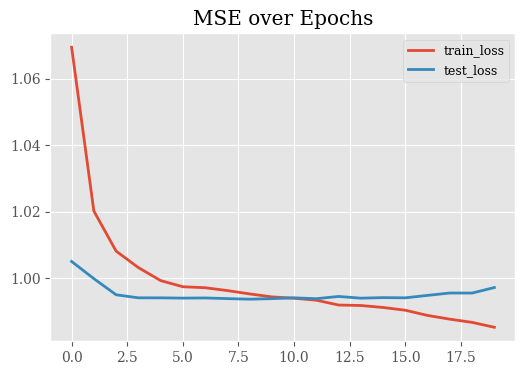

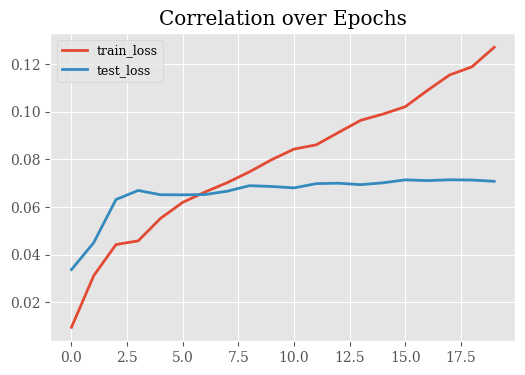

Running model: top3_sparse_attention_TC


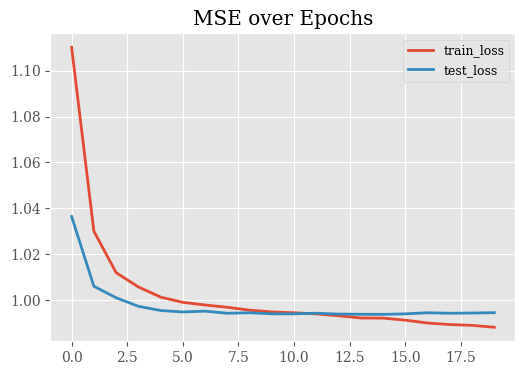

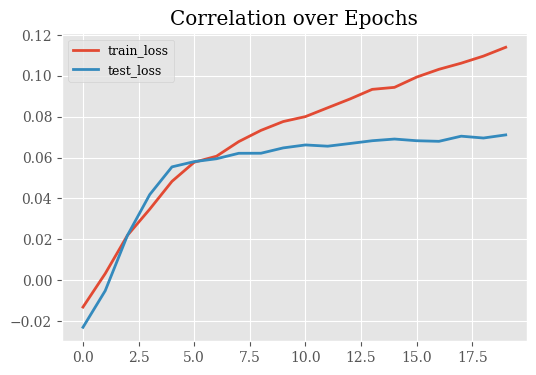

Running model: full_attention_TCTC


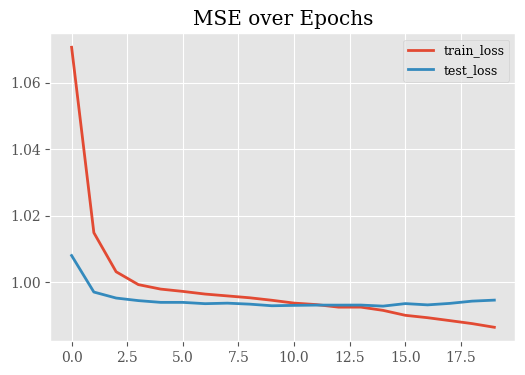

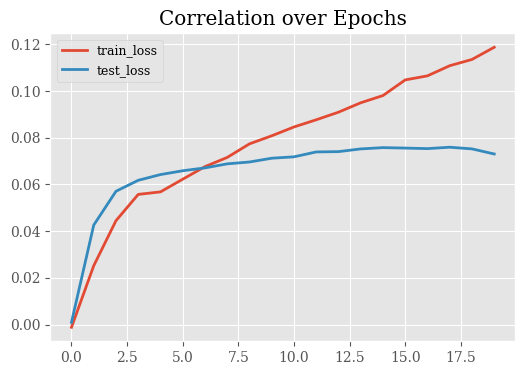

Running model: top3_sparse_attention_TCTC


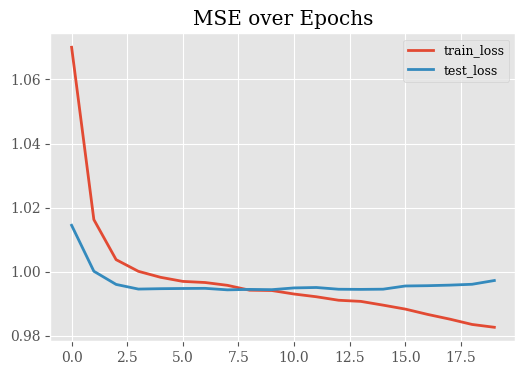

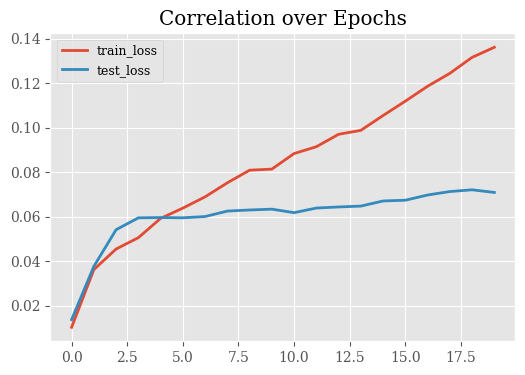

In [215]:
# Code to run the model with the parameters above.

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    print("Running model:", k)
    models_torch[k].fit(z.train, test=z.test, epochs=20, plot=True, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)


In [216]:
corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [217]:
corr_test

,true,optimal,linear,conditional,shift,cs,cs_shift,conditional_ts,conditional_cs,full_attention_TC,top3_sparse_attention_TC,full_attention_TCTC
optimal,0.214633,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
linear,0.079337,0.370948,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conditional,0.070174,0.388539,-0.001273,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,0.081939,0.374635,-0.007960,0.011772,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cs,0.078600,0.373276,0.006089,-0.000091,-0.002490,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cs_shift,0.083453,0.382195,0.000194,-0.003953,0.001066,-0.003373,NaN,NaN,NaN,NaN,NaN,NaN
conditional_ts,0.087772,0.388117,0.010085,0.004582,0.002755,-0.003193,0.011968,NaN,NaN,NaN,NaN,NaN
conditional_cs,0.086958,0.369534,-0.019678,0.012138,-0.009571,-0.003293,-0.000318,-0.001435,NaN,NaN,NaN,NaN
full_attention_TC,0.070972,0.408706,0.636349,0.318505,-0.006372,0.149226,-0.002375,0.003726,-0.014559,NaN,NaN,NaN
top3_sparse_attention_TC,0.068709,0.371416,0.671104,0.252743,0.000408,0.066618,-0.000729,0.009106,-0.013367,0.762332,NaN,NaN


In [221]:
table_sum_effects1 = corr_test.loc["full_attention_TC":]
table_sum_effects1 = table_sum_effects1.loc[:, "optimal":"conditional_cs"]

In [222]:
table_sum_effects1

,optimal,linear,conditional,shift,cs,cs_shift,conditional_ts,conditional_cs
full_attention_TC,0.408706,0.636349,0.318505,-0.006372,0.149226,-0.002375,0.003726,-0.014559
top3_sparse_attention_TC,0.371416,0.671104,0.252743,0.000408,0.066618,-0.000729,0.009106,-0.013367
full_attention_TCTC,0.388064,0.660375,0.343621,0.001595,0.027541,-0.007909,0.013064,-0.009059
top3_sparse_attention_TCTC,0.384826,0.567937,0.358034,0.009110,0.089554,-0.000120,0.004819,-0.008923


# Run of transformers and Global MLP and the order 2 effects

Here we will run our models and the three order 2 effects that are very hard to find and see what is the best we can do.

In [21]:
def run_models2_new_effects_bothemb_v2(rhos, effect, T=4000, n_ts=10, n_f=5, n_rolling=10):

    list_effects1 = [effect]*n_f
    correl_split_by_fea1 = [1/np.sqrt(n_f)]*n_f

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []

    for (i,rho) in enumerate(rhos):
        print("Running correl level:", rho)
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


        z.generate_dataset_gr_simple(
            global_corr=rho, 
            correl_split_by_fea=correl_split_by_fea1, 
            list_type_effects=list_effects1,
            list_type_interaction=["cond"], 
            random_ts_shift=n_rolling,
        )



        models_torch = {
        'Global_MLP': models.GlobalMLP(n_ts, n_f, n_rolling, dropout=0.1).to(device),
        '1D_Trans_TT': models.OneDimensionalTransformer(n_ts, n_f, n_rolling, mask=mask_c, attn_direction="T",  num_attn_layers=2,
                                        d_model=64, dim_feedforward=256, nhead=8, compression="MLP", num_mlp_layers=2,
                                        dropout=0.1, roll_y=True).to(device),
        '1D_Trans_CC': models.OneDimensionalTransformer(n_ts, n_f, n_rolling, mask=mask_c, attn_direction="C",  num_attn_layers=2,
                                        d_model=64, dim_feedforward=256, nhead=8, compression="MLP", num_mlp_layers=2,
                                        dropout=0.1,  roll_y=False).to(device),                                
        '2D_Trans_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        '2D_Trans_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }

        
        for k in models_torch:
            roll_y = True
            if k in ['Global_MLP', '1D_Trans_CC']:
                roll_y = False
            z.get_dataloader(n_rolling=n_rolling, roll_y=roll_y)
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test

In [22]:
new_effects2_bothemb_train_dic_v2 = {}
new_effects2_bothemb_test_dic_v2 = {}

In [23]:
for effect in ['TSCS_shift', 'TS_cond', 'CS_cond']:
#for effect in ['TSCS_shift']:
    print("Running_effect:", effect)
    out_train1, out_test1 = run_models2_new_effects_bothemb_v2([0.1, 0.2, 0.5], effect, T=4000, n_ts=10, n_f=5, n_rolling=10)
    new_effects2_bothemb_train_dic_v2[effect] = out_train1
    new_effects2_bothemb_test_dic_v2[effect] = out_test1

Running_effect: TSCS_shift
Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


...

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [24]:
for effect in ['TSCS_shift', 'TS_cond', 'CS_cond']:
    print(effect)
    display(new_effects2_bothemb_train_dic_v2[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
    display(new_effects2_bothemb_test_dic_v2[effect].T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

TSCS_shift


rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,0.093,0.215,0.669
1D_Trans_TT,0.075,0.189,0.434
2D_Trans_TC,0.018,0.057,0.213
2D_Trans_TCTC,0.012,0.016,0.266
Global_MLP,0.102,0.202,0.503
theo_correl,0.219,0.415,0.791


rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,0.053,0.122,0.631
1D_Trans_TT,0.020,0.083,0.085
2D_Trans_TC,0.010,0.010,0.064
2D_Trans_TCTC,0.007,-0.010,0.065
Global_MLP,0.184,0.304,0.655
theo_correl,0.197,0.378,0.756


TS_cond


rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,0.099,0.209,0.603
1D_Trans_TT,0.070,0.151,0.388
2D_Trans_TC,0.010,0.114,0.583
2D_Trans_TCTC,0.038,0.067,0.554
Global_MLP,0.098,0.197,0.496
theo_correl,0.219,0.415,0.791


rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,0.046,0.113,0.487
1D_Trans_TT,-0.011,-0.007,-0.009
2D_Trans_TC,0.007,0.064,0.494
2D_Trans_TCTC,0.014,0.035,0.483
Global_MLP,0.011,-0.000,-0.005
theo_correl,0.197,0.378,0.756


CS_cond


rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,0.062,0.144,0.349
1D_Trans_TT,0.090,0.186,0.424
2D_Trans_TC,0.033,0.083,0.291
2D_Trans_TCTC,0.066,0.083,0.098
Global_MLP,0.096,0.208,0.487
theo_correl,0.219,0.415,0.791


rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,-0.012,0.005,0.002
1D_Trans_TT,0.031,0.060,0.094
2D_Trans_TC,0.019,0.039,0.177
2D_Trans_TCTC,0.026,0.047,0.043
Global_MLP,0.004,0.004,0.004
theo_correl,0.197,0.378,0.756


## All effects

In [25]:
# Let's also run the above models on the superposition of all 7 effects to see what it gives.

In [26]:
def run_models2_allnew_effects_bothemb_v2(rhos, T=4000, n_ts=10, n_rolling=10):
    n_f=7
    list_effects1 = ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']
    correl_split_by_fea1 = [1/np.sqrt(n_f)]*n_f
    
    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)
    
    z = generators.Generator(T, n_ts, n_f)
    
    res_train = []
    res_test = []

    for (i,rho) in enumerate(rhos):
        print("Running correl level:", rho)
        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


        z.generate_dataset_gr_simple(
            global_corr=rho, 
            correl_split_by_fea=correl_split_by_fea1, 
            list_type_effects=list_effects1,
            list_type_interaction=["cond"], 
            random_ts_shift=n_rolling,
        )



        models_torch = {
        'Global_MLP': models.GlobalMLP(n_ts, n_f, n_rolling, dropout=0.1).to(device),
        '1D_Trans_TT': models.OneDimensionalTransformer(n_ts, n_f, n_rolling, mask=mask_c, attn_direction="T",  num_attn_layers=2,
                                        d_model=64, dim_feedforward=256, nhead=8, compression="MLP", num_mlp_layers=2,
                                        dropout=0.1, roll_y=True).to(device),
        '1D_Trans_CC': models.OneDimensionalTransformer(n_ts, n_f, n_rolling, mask=mask_c, attn_direction="C",  num_attn_layers=2,
                                        d_model=64, dim_feedforward=256, nhead=8, compression="MLP", num_mlp_layers=2,
                                        dropout=0.1,  roll_y=False).to(device),                                
        '2D_Trans_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        '2D_Trans_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }

        
        for k in models_torch:
            roll_y = True
            if k in ['Global_MLP', '1D_Trans_CC']:
                roll_y = False
            z.get_dataloader(n_rolling=n_rolling, roll_y=roll_y)
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test

In [27]:
out_alleffects_train1, out_alleffects_test1 = run_models2_allnew_effects_bothemb_v2([0.1, 0.2, 0.5], T=4000, n_ts=10, n_rolling=10)

Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [28]:
display(out_alleffects_test1.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.100000,0.200000,0.500000
model,,,
1D_Trans_CC,0.106,0.168,0.517
1D_Trans_TT,0.064,0.121,0.278
2D_Trans_TC,0.113,0.261,0.615
2D_Trans_TCTC,0.125,0.222,0.592
Global_MLP,0.085,0.154,0.399
theo_correl,0.159,0.311,0.679


In [30]:
# Let's see which correlations each of these models is picking up.

In [31]:
# Parameters

T=4000
n_rolling = 10
n_f = 7
n_ts = 10

rho = 0.5

# The possible effects are: lin, TS_shift, CS_shift, TSCS_shift, fea_cond, TS_cond, CS_cond

#list_effects1 = ["lin", "TS_shift", "CS_shift", "TSCS_shift", "fea_cond", "TS_cond", "CS_cond"]*2
list_effects1 = ["lin", "TS_shift", "CS_shift", "TSCS_shift", "fea_cond", "TS_cond", "CS_cond"]

print(list_effects1)

['lin', 'TS_shift', 'CS_shift', 'TSCS_shift', 'fea_cond', 'TS_cond', 'CS_cond']


In [32]:
# Define the data:

z = generators.Generator(T, n_ts, n_f)

z.generate_dataset_gr_simple(
        global_corr=rho, 
        correl_split_by_fea=None, 
        list_type_effects=list_effects1,
        list_type_interaction=["cond"], 
        random_ts_shift=n_rolling,
    )

z.get_dataloader()


In [33]:
# Define the models

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)


models_torch = {
        'Global_MLP': models.GlobalMLP(n_ts, n_f, n_rolling, dropout=0.1).to(device),
        '1D_Trans_TT': models.OneDimensionalTransformer(n_ts, n_f, n_rolling, mask=mask_c, attn_direction="T",  num_attn_layers=2,
                                        d_model=64, dim_feedforward=256, nhead=8, compression="MLP", num_mlp_layers=2,
                                        dropout=0.1, roll_y=True).to(device),
        '1D_Trans_CC': models.OneDimensionalTransformer(n_ts, n_f, n_rolling, mask=mask_c, attn_direction="C",  num_attn_layers=2,
                                        d_model=64, dim_feedforward=256, nhead=8, compression="MLP", num_mlp_layers=2,
                                        dropout=0.1,  roll_y=False).to(device),                                
        '2D_Trans_TC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        '2D_Trans_TCTC': models.CustomBiDimensionalTransformer(
            n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
            dropout=0.1, d_model=64, dim_feedforward=256, sparsify=None, roll_y=True, embeddings="both",
        ).to(device),
        }

In [34]:
# Code to run the model with the parameters above.

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)


models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


for k in models_torch:
    roll_y = True
    if k in ['Global_MLP', '1D_Trans_CC']:
        roll_y = False
    z.get_dataloader(n_rolling=n_rolling, roll_y=roll_y)
    models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)


Running correl level: 0.5


In [35]:
corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [37]:
corr_test

,true,optimal,linear,conditional,shift,cs,cs_shift,conditional_ts,conditional_cs,Global_MLP,1D_Trans_TT,1D_Trans_CC,2D_Trans_TC
optimal,0.505119,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
linear,0.198517,0.379687,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conditional,0.195372,0.373140,-0.009418,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
shift,0.192877,0.388250,0.008343,0.000153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cs,0.188183,0.379291,0.008982,0.001641,0.002564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
cs_shift,0.197305,0.390378,0.012273,0.007589,0.011517,-0.004502,NaN,NaN,NaN,NaN,NaN,NaN,NaN
conditional_ts,0.183355,0.374341,0.002904,-0.003808,0.007810,0.000632,0.001220,NaN,NaN,NaN,NaN,NaN,NaN
conditional_cs,0.195707,0.390054,-0.003587,0.008301,0.004466,0.015101,0.011396,-0.005206,NaN,NaN,NaN,NaN,NaN
Global_MLP,0.199633,0.389523,0.260535,0.005694,0.243515,0.259746,0.263726,0.006403,0.003825,NaN,NaN,NaN,NaN
1D_Trans_TT,0.134183,0.261207,0.295971,0.015562,0.000294,0.319311,0.037865,-0.001976,0.035475,0.236629,NaN,NaN,NaN


In [39]:
table_sum_effects2 = corr_test.loc["Global_MLP":]
table_sum_effects2 = table_sum_effects2.loc[:, "optimal":"conditional_cs"]

In [40]:
table_sum_effects2

,optimal,linear,conditional,shift,cs,cs_shift,conditional_ts,conditional_cs
Global_MLP,0.389523,0.260535,0.005694,0.243515,0.259746,0.263726,0.006403,0.003825
1D_Trans_TT,0.261207,0.295971,0.015562,0.000294,0.319311,0.037865,-0.001976,0.035475
1D_Trans_CC,0.495584,0.373042,0.114778,0.325302,0.228361,0.139915,0.136116,0.010929
2D_Trans_TC,0.578353,0.467299,0.356347,0.207421,0.409873,0.004113,0.013143,0.095090
2D_Trans_TCTC,0.505762,0.353596,0.284863,0.130556,0.345928,0.007556,0.015411,0.218323


In [42]:
display(table_sum_effects2.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

,optimal,linear,conditional,shift,cs,cs_shift,conditional_ts,conditional_cs
Global_MLP,0.390,0.261,0.006,0.244,0.260,0.264,0.006,0.004
1D_Trans_TT,0.261,0.296,0.016,0.000,0.319,0.038,-0.002,0.035
1D_Trans_CC,0.496,0.373,0.115,0.325,0.228,0.140,0.136,0.011
2D_Trans_TC,0.578,0.467,0.356,0.207,0.410,0.004,0.013,0.095
2D_Trans_TCTC,0.506,0.354,0.285,0.131,0.346,0.008,0.015,0.218


# Experiments at fixed theo correl

In [19]:
# Lets run here some experiemnts where we vary gamma and rho while keeping the theo correl level fixed.

Recall the formula for the theo correl level $C$ as a function of $\rho$, and $\gamma$:
$$ C(\rho, \gamma) = \frac{\rho}{\sqrt{\rho^2 + (1-\rho^2) \frac{\gamma}{1-\gamma} }} $$

In [ ]:
def C_theo_formula(rho, gamma, oos=True):
    ratio = gamma
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)

In [24]:
# If we take rho = 0.1 and gamma = 0.8 of the default data:
C_default = C_theo_formula(0.1, 0.8)
print(C_default)

0.05018856132284956


In [25]:
# The default theo correl level is around 5%

In [29]:
def solve_C_equation(C, rho=None, gamma=None):
    """
    Solve C(rho, gamma) = rho / sqrt(rho^2 + (1-rho^2) * gamma/(1-gamma))
    
    Given C and either rho or gamma, finds the other parameter.
    
    Parameters:
    -----------
    C : float
        Value of C in (0, 1)
    rho : float, optional
        Value of rho in (0, 1). If provided, gamma is computed.
    gamma : float, optional
        Value of gamma in (0, 1). If provided, rho is computed.
    
    Returns:
    --------
    float
        The computed value of either rho or gamma
        
    Raises:
    -------
    ValueError
        If both or neither of rho and gamma are provided, or if values are out of range
    """
    # Validate inputs
    if (rho is None and gamma is None) or (rho is not None and gamma is not None):
        raise ValueError("Exactly one of rho or gamma must be provided")
    
    if not (0 < C < 1):
        raise ValueError("C must be in the interval (0, 1)")
    
    if rho is not None:
        # Solve for gamma given C and rho
        if not (0 < rho < 1):
            raise ValueError("rho must be in the interval (0, 1)")
        
        numerator = rho**2 * (1 - C**2)
        denominator = C**2 * (1 - rho**2) + rho**2 * (1 - C**2)
        gamma_result = numerator / denominator
        
        return gamma_result
    
    else:
        # Solve for rho given C and gamma
        if not (0 < gamma < 1):
            raise ValueError("gamma must be in the interval (0, 1)")
        
        numerator = C
        denominator = np.sqrt(C**2 + (1 - C**2) * (1 - gamma) / gamma)
        rho_result = numerator / denominator
        
        return rho_result


In [34]:
# Let's vary gamma and coompute the associated rhos
list_of_gammas = [0.08, 0.2, 0.4, 0.6, 0.8, 0.92]
list_of_rhos = [solve_C_equation(0.05, gamma=x) for x in list_of_gammas]
print(list_of_rhos)

[np.float64(0.014761052093103138), np.float64(0.025023470510567424), np.float64(0.040841850030676544), np.float64(0.06119900613621046), np.float64(0.09962709627734359), np.float64(0.16737567422286637)]


In [35]:
# Next we have to make some data choices that correspond to these values of gamma.
# We keep:
n_ts = 10
n_rolling = 10
# and simply vary the number of features
list_n_f = [2,5,10,15,20,22]

In [36]:
# Let's now write the code to run all of this.

In [ ]:
def run_models1_vary_numfea(rhos, list_n_f, effect, T=4000, n_ts=10, n_rolling=10):

    embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}
    pct_zero_corr = 0.5

    arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
                'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
                'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
                'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
                'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
               }

    mask = causal_mask
    mask_c = build_attention_mask(mask, n_rolling, device=device)

        
    res_train = []
    res_test = []
    for (i,rho) in enumerate(rhos):
        
        print("Running correl level:", rho)
        n_f = list_n_f[i]
        c = rho/np.sqrt((1-pct_zero_corr)*n_f)
        z = generators.Generator(T, n_ts, n_f)

        theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rhos[i], oos=False)
        theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rhos[i], oos=True)

        z.generate_dataset(
                pct_zero_corr=arg_list[effect]['pct_zero_corr'],
                split_conditional=arg_list[effect]['split_conditional'],
                split_shift=arg_list[effect]['split_shift'],
                split_seasonal=arg_list[effect]['split_seasonal'],
                split_cs=arg_list[effect]['split_cs'],
                split_cs_shift=arg_list[effect]['split_cs_shift'],
                random_ts_shift=n_rolling-1,
                low_corr=c,
                high_corr=c,
                shuffle_cs=True
            )

        z.get_dataloader()


        models_torch = {
            'full_attention_TC': models.CustomBiDimensionalTransformer(
                n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
                dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
            ).to(device),
            'full_attention_TCTC': models.CustomBiDimensionalTransformer(
                n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
                dropout=0.1, dim_feedforward=256, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
            ).to(device),
        }

        models_torch = {
            k: torch_benchmarks.TorchWrapper(
                models_torch[k], 
                optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
                loss_fn=nn.MSELoss()  
            ) for k in models_torch
        }


        z.get_dataloader(n_rolling=n_rolling, roll_y=True)
        for k in models_torch:
            models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
            
      
        comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
        model_names=[k for k in models_torch]
        )

        corr_train = comp.correl(z, mode="train", return_values=True)
        corr_test  = comp.correl(z, mode="test",  return_values=True)

        for k in models_torch:

            train_corr = corr_train.loc[k, "optimal"]
            test_corr  = corr_test.loc[k, "optimal"]

            res_train.append({
                "rho": rhos[i],
                "model": k,
                "train_corr_optimal": train_corr
            })
            res_test.append({
                "rho": rhos[i],
                "model": k,
                "test_corr_optimal": test_corr
            })


        res_train.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "train_corr_optimal": theo_correl_is
            })
        res_test.append({
                "rho": rhos[i],
                "model": "theo_correl",
                "test_corr_optimal": theo_correl_oos
            })

    
    res_train = pd.DataFrame(res_train)
    res_test  = pd.DataFrame(res_test)

    res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
    res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

    return res_train, res_test


In [46]:
print(list_of_rhos)
print(list_n_f)

[np.float64(0.014761052093103138), np.float64(0.025023470510567424), np.float64(0.040841850030676544), np.float64(0.06119900613621046), np.float64(0.09962709627734359), np.float64(0.16737567422286637)]
[2, 5, 10, 15, 20, 22]


In [47]:
res1_vary_gamma_train, res1_vary_gamma_test = run_models1_vary_numfea(list_of_rhos, list_n_f, "d_lin", T=4000, n_ts=10, n_rolling=10)

Running correl level: 0.014761052093103138


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.025023470510567424


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.040841850030676544


...

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.09962709627734359


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.16737567422286637


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [48]:
display(res1_vary_gamma_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(res1_vary_gamma_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.014761,0.025023,0.040842,0.061199,0.099627,0.167376
model,,,,,,
full_attention_TC,0.454,-0.023,0.055,0.074,0.108,0.198
full_attention_TCTC,0.763,-0.003,0.043,0.054,0.101,0.183
theo_correl,0.052,0.056,0.064,0.079,0.111,0.178


rho,0.014761,0.025023,0.040842,0.061199,0.099627,0.167376
model,,,,,,
full_attention_TC,0.477,-0.023,0.083,0.092,0.122,0.249
full_attention_TCTC,0.770,-0.003,0.087,0.068,0.140,0.262
theo_correl,0.050,0.050,0.050,0.050,0.050,0.063


In [49]:
# These results make no sense....

# Generating the plots for the paper

## Tables per effect

In [179]:
def generate_latex_table1(data_dic_in, effect, effect_name):

    table_to_plot1 = data_dic_in[effect]

    rename_cols_dict1 = {'full_attention_TC': "TC", 'full_attention_TCTC': "TC2", 'theo_correl': "TheoC",
        'top3_sparse_attention_TC': "TC-Spa", 'top3_sparse_attention_TCTC': "TC2-Spa"}

    table_to_plot1 = table_to_plot1.rename(columns=rename_cols_dict1)
    table_to_plot1 = table_to_plot1.loc[:, ["TheoC", "TC", "TC2", "TC-Spa", "TC2-Spa"]]

    correlation_levels = list(table_to_plot1.index)
    data = {k:table_to_plot1[k].values for k in list(table_to_plot1.columns)}

    # Create DataFrame
    df = pd.DataFrame(data, index=correlation_levels).T
    df.index.name = 'Model'
    df.columns.name = 'Correlation Level'


    def style_table(df):
        styled = df.style.background_gradient(
            cmap='coolwarm',
            axis=0,
            vmin=None,
            vmax=None,
            subset=None
        )
        styled = styled.format("{:.3f}")
        return styled
    
    # Format the dataframe
    df_formatted = df.copy()
    df_formatted.columns = [f'{col:.2f}' for col in df_formatted.columns]
    df_formatted.columns.name = r'$\rho$'
    df_formatted.index.name = None

    # Create styled table
    styled_df = style_table(df_formatted.round(3))

    # Export to LaTeX (just the tabular part)
    tabular_latex = styled_df.to_latex(
        column_format='l' + 'c' * len(df_formatted.columns),
        hrules=True,
        convert_css=True
    )

    # Wrap in proper table environment
    caption = "Model performance for effect " + effect_name
    label = "tab:model_performance"

    latex_table = f"""\\begin{{table}}[t]
    \\centering
    \\caption{{{caption}}}
    \\label{{{label}}}
    {tabular_latex}
    \\end{{table}}
    """

    return latex_table
    

# # Save to file
# with open('table.tex', 'w') as f:
#     f.write(latex_table)
    


In [180]:
new_effects2_test_dic.keys()

dict_keys(['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond'])

In [181]:
effect_name_dic = {'lin': "Linear", 'TS_shift': "TS-Shift", 'CS_shift': "CS-Shift", 'fea_cond': "Fea-Nonlin", 'TSCS_shift': "TSCS-Shift",
                     'TS_cond': "TS-Nonlin", 'CS_cond': "CS-Nonlin"}

In [182]:
for effect in ['lin', 'TS_shift', 'CS_shift', 'fea_cond', 'TSCS_shift', 'TS_cond', 'CS_cond']:
    effect_name = effect_name_dic[effect]
    print(effect_name)
    print('\n')
    latex_test = generate_latex_table1(new_effects2_test_dic, effect, effect_name)
    print(latex_test)
    print('\n')

Linear


\begin{table}[t]
    \centering
    \caption{Model performance for effect Linear}
    \label{tab:model_performance}
    \begin{tabular}{lccccc}
\toprule
$\rho$ & 0.02 & 0.05 & 0.10 & 0.20 & 0.50 \\
\midrule
TheoC & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.040 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.100 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.197 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.378 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.756 \\
TC & {\cellcolor[HTML]{5977E3}} \color[HTML]{F1F1F1} 0.067 & {\cellcolor[HTML]{C43032}} \color[HTML]{F1F1F1} 0.411 & {\cellcolor[HTML]{F29274}} \color[HTML]{F1F1F1} 0.558 & {\cellcolor[HTML]{B50927}} \color[HTML]{F1F1F1} 0.952 & {\cellcolor[HTML]{C53334}} \color[HTML]{F1F1F1} 0.981 \\
TC2 & {\cellcolor[HTML]{5875E1}} \color[HTML]{F1F1F1} 0.066 & {\cellcolor[HTML]{E3D9D3}} \color[HTML]{000000} 0.271 & {\cellcolor[HTML]{F7B79B}} \color[HTML]{000000} 0.512 & {\cellcolor[HTML]{F18F71}} \color[H

## Tables sum of effects

In [223]:
table_sum_effects1

,optimal,linear,conditional,shift,cs,cs_shift,conditional_ts,conditional_cs
full_attention_TC,0.408706,0.636349,0.318505,-0.006372,0.149226,-0.002375,0.003726,-0.014559
top3_sparse_attention_TC,0.371416,0.671104,0.252743,0.000408,0.066618,-0.000729,0.009106,-0.013367
full_attention_TCTC,0.388064,0.660375,0.343621,0.001595,0.027541,-0.007909,0.013064,-0.009059
top3_sparse_attention_TCTC,0.384826,0.567937,0.358034,0.009110,0.089554,-0.000120,0.004819,-0.008923


In [231]:
process_sum_effects_table1 = table_sum_effects1.copy()

In [234]:
rename_cols_dict1 = {'full_attention_TC': "TC", 'full_attention_TCTC': "TC2", 'theo_correl': "TheoC",
        'top3_sparse_attention_TC': "TC-Spa", 'top3_sparse_attention_TCTC': "TC2-Spa"}


rename_cols_dict2 = {'optimal': "Optimal", 'linear': "Linear", 'shift': "TS-Shift", 'cs': "CS-Shift", 'conditional': "Fea-Nonlin", 'cs_shift': "TSCS-Shift",
                     'conditional_ts': "TS-Nonlin", 'conditional_cs': "CS-Nonlin"}

process_sum_effects_table1 = process_sum_effects_table1.T.rename(columns=rename_cols_dict1).T.rename(columns=rename_cols_dict2).round(3)



In [235]:
process_sum_effects_table1

,Optimal,Linear,Fea-Nonlin,TS-Shift,CS-Shift,TSCS-Shift,TS-Nonlin,CS-Nonlin
TC,0.409,0.636,0.319,-0.006,0.149,-0.002,0.004,-0.015
TC-Spa,0.371,0.671,0.253,0.000,0.067,-0.001,0.009,-0.013
TC2,0.388,0.660,0.344,0.002,0.028,-0.008,0.013,-0.009
TC2-Spa,0.385,0.568,0.358,0.009,0.090,-0.000,0.005,-0.009


In [240]:
def generate_latex_table2(table_in):

    def style_table(df):
        styled = df.style.background_gradient(
            cmap='coolwarm',
            axis=0,
            vmin=None,
            vmax=None,
            subset=None
        )
        styled = styled.format("{:.3f}")
        return styled
    
    # Format the dataframe
    df_formatted = table_in
    df_formatted.columns.name = r'Effect'
    df_formatted.index.name = None

    # Create styled table
    styled_df = style_table(df_formatted.round(3))

    # Export to LaTeX (just the tabular part)
    tabular_latex = styled_df.to_latex(
        column_format='l' + 'c' * len(df_formatted.columns),
        hrules=True,
        convert_css=True
    )

    # Wrap in proper table environment
    caption = "Model performance on superposition of effects, $\rho =0.2$"
    label = "tab:model_performance"

    latex_table = f"""\\begin{{table*}}[t]
    \\centering
    \\caption{{{caption}}}
    \\label{{{label}}}
    {tabular_latex}
    \\end{{table*}}
    """

    return latex_table

In [241]:
print(generate_latex_table2(process_sum_effects_table1))

\begin{table*}[t]
    \centering
ho =0.2$}ion{Model performance on superposition of effects, $
    \label{tab:model_performance}
    \begin{tabular}{lcccccccc}
\toprule
Effect & Optimal & Linear & Fea-Nonlin & TS-Shift & CS-Shift & TSCS-Shift & TS-Nonlin & CS-Nonlin \\
\midrule
TC & {\cellcolor[HTML]{B40426}} \color[HTML]{F1F1F1} 0.409 & {\cellcolor[HTML]{F7B99E}} \color[HTML]{000000} 0.636 & {\cellcolor[HTML]{F5C4AC}} \color[HTML]{000000} 0.319 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} -0.006 & {\cellcolor[HTML]{B40426}} \color[HTML]{F1F1F1} 0.149 & {\cellcolor[HTML]{F4987A}} \color[HTML]{000000} -0.002 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.004 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} -0.015 \\
TC-Spa & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.371 & {\cellcolor[HTML]{B40426}} \color[HTML]{F1F1F1} 0.671 & {\cellcolor[HTML]{3B4CC0}} \color[HTML]{F1F1F1} 0.253 & {\cellcolor[HTML]{C0D4F5}} \color[HTML]{000000} 0.000 & {\cellcolor[HTML]{A6C4FE}} \col

# Placeholder tables

In [43]:
# Let's create the format of the tables that we want so we can put them in the paper and start formatting things.

In [45]:
# Define rows and columns
rows = ["TheoC", "Lasso", "Boosting", "MLP", "Trans", "SpTrans"]
columns = [0.02, 0.05, 0.1, 0.2, 0.5]

# Create DataFrame with random values between 0 and 1
df = pd.DataFrame(
    np.random.rand(len(rows), len(columns)),
    columns=columns,
    index=rows
)

print(df)


              0.02      0.05      0.10      0.20      0.50
TheoC     0.544818  0.517186  0.960455  0.173749  0.932552
Lasso     0.002894  0.879534  0.107462  0.713089  0.006157
Boosting  0.156241  0.521356  0.574707  0.587177  0.536332
MLP       0.820274  0.301721  0.930244  0.515901  0.317843
Trans     0.615391  0.470519  0.962225  0.779795  0.517597
SpTrans   0.379245  0.423361  0.187434  0.808308  0.304290


# Old sections below

## Running on all effects, default data 1

In [ ]:
tfull_lin_train, tfull_lin_test = run_models([0.02, 0.05, 0.1, 0.2, 0.5], 'd_lin')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
display(tfull_lin_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_lin_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.062,0.087,0.138,0.258,0.647
full_attention_TCTC,0.012,0.077,0.131,0.227,0.564
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.074,0.124,0.139,0.294,0.662
full_attention_TCTC,0.014,0.090,0.156,0.259,0.617
theo_correl,0.010,0.025,0.050,0.102,0.277


In [ ]:
tfull_shift_train, tfull_shift_test = run_models([0.02, 0.05, 0.1, 0.2, 0.5], 'd_shift')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
display(tfull_shift_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_shift_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.012,0.049,0.111,0.250,0.540
full_attention_TCTC,0.015,0.050,0.106,0.231,0.525
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.007,0.033,0.079,0.197,0.440
full_attention_TCTC,0.008,0.022,0.066,0.200,0.397
theo_correl,0.010,0.025,0.050,0.102,0.277


In [ ]:
tfull_cond_train, tfull_cond_test = run_models([0.02, 0.05, 0.1, 0.2, 0.5], 'd_cond')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
display(tfull_cond_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_cond_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.032,0.087,0.129,0.252,0.535
full_attention_TCTC,0.022,0.090,0.102,0.236,0.489
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.036,0.085,0.128,0.245,0.476
full_attention_TCTC,0.027,0.088,0.133,0.242,0.479
theo_correl,0.010,0.025,0.050,0.102,0.277


In [ ]:
tfull_cs_train, tfull_cs_test = run_models([0.02, 0.05, 0.1, 0.2, 0.5], 'd_cs')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
display(tfull_cs_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_cs_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.028,0.056,0.115,0.225,0.519
full_attention_TCTC,0.020,0.048,0.106,0.207,0.471
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.019,0.053,0.088,0.204,0.510
full_attention_TCTC,0.019,0.062,0.082,0.224,0.530
theo_correl,0.010,0.025,0.050,0.102,0.277


In [ ]:
tfull_cs_shift_train, tfull_cs_shift_test = run_models([0.02, 0.05, 0.1, 0.2, 0.5], 'd_cs_shift')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
display(tfull_cs_shift_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_cs_shift_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.020,0.043,0.088,0.156,0.359
full_attention_TCTC,0.023,0.041,0.094,0.186,0.394
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,-0.000,0.013,0.003,-0.004,0.001
full_attention_TCTC,0.002,-0.002,0.003,0.012,0.006
theo_correl,0.010,0.025,0.050,0.102,0.277


In [ ]:
tfull_all_train, tfull_all_test = run_models([0.02, 0.05, 0.1, 0.2, 0.5], 'd_all')

Running correl level: 0.02


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.2


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Running correl level: 0.5


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [ ]:
display(tfull_all_train.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))
display(tfull_all_test.T.style.background_gradient(cmap='coolwarm', vmin=-1, vmax=1).format(precision=3))

rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.038,0.081,0.124,0.231,0.518
full_attention_TCTC,0.029,0.073,0.115,0.214,0.476
theo_correl,0.022,0.056,0.112,0.222,0.542


rho,0.020000,0.050000,0.100000,0.200000,0.500000
model,,,,,
full_attention_TC,0.010,0.074,0.110,0.181,0.430
full_attention_TCTC,0.012,0.065,0.107,0.146,0.380
theo_correl,0.010,0.025,0.050,0.102,0.277


## Interpretability experiment

In [15]:
# In this section let's try to run an experiment to try to see how the model learns when there are many effects at once.

In [16]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [17]:
def get_ols_corr(N_fea, T_train, rho, oos=True):
    ratio = N_fea/T_train
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)


In [22]:
# Parameters

T=4000
n_rolling = 10
n_f = 12
n_ts = 10

rho = 0.05
effect = 'd_all'


In [23]:
# Code to run the model with the parameters above.

embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)

if n_f < 10:
    pct_zero_corr = 0
else:
    pct_zero_corr = 0.5

c = rho/np.sqrt((1-pct_zero_corr)*n_f)

arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
            'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
            'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
            'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
            }

z = generators.Generator(T, n_ts, n_f)

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)

z.generate_dataset(
        pct_zero_corr=arg_list[effect]['pct_zero_corr'],
        split_conditional=arg_list[effect]['split_conditional'],
        split_shift=arg_list[effect]['split_shift'],
        split_seasonal=arg_list[effect]['split_seasonal'],
        split_cs=arg_list[effect]['split_cs'],
        split_cs_shift=arg_list[effect]['split_cs_shift'],
        random_ts_shift=n_rolling-1,
        low_corr=c,
        high_corr=c,
        shuffle_cs=True
    )

z.get_dataloader()


models_torch = {
    'full_attention_TC': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=8,
        dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
    ).to(device),

}

models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

for k in models_torch:

    train_corr = corr_train.loc[k, "optimal"]
    test_corr  = corr_test.loc[k, "optimal"]

    res_train.append({
        "rho": rho,
        "model": k,
        "train_corr_optimal": train_corr
    })
    res_test.append({
        "rho": rho,
        "model": k,
        "test_corr_optimal": test_corr
    })


res_train.append({
        "rho": rho,
        "model": "theo_correl",
        "train_corr_optimal": theo_correl_is
    })
res_test.append({
        "rho": rho,
        "model": "theo_correl",
        "test_corr_optimal": theo_correl_oos
    })


res_train = pd.DataFrame(res_train)
res_test  = pd.DataFrame(res_test)

res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [24]:
res_train

model,full_attention_TC,theo_correl
rho,,
0.05,0.210503,0.072071


In [25]:
res_test

model,full_attention_TC,theo_correl
rho,,
0.05,0.206541,0.052036


In [26]:
# Ok let's try to visualize what different attention heads are learning.

In [28]:
pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_2962/169484065.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.521,0.479,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.407,0.280,0.313,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.231,0.305,0.252,0.212,0.000,0.000,0.000,0.000,0.000,0.000
4,0.218,0.207,0.223,0.166,0.185,0.000,0.000,0.000,0.000,0.000
5,0.163,0.165,0.194,0.148,0.162,0.168,0.000,0.000,0.000,0.000
6,0.147,0.172,0.139,0.125,0.129,0.135,0.153,0.000,0.000,0.000
7,0.118,0.124,0.115,0.136,0.118,0.137,0.129,0.123,0.000,0.000
8,0.127,0.106,0.121,0.093,0.110,0.110,0.117,0.115,0.100,0.000
9,0.123,0.122,0.110,0.087,0.090,0.088,0.091,0.108,0.090,0.090


In [30]:
pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_2962/2185950073.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,0.088,0.090,0.083,0.101,0.091,0.095,0.098,0.067,0.095,0.192
1,0.083,0.078,0.075,0.104,0.087,0.091,0.097,0.058,0.093,0.234
2,0.086,0.084,0.073,0.097,0.087,0.086,0.101,0.061,0.091,0.234
3,0.088,0.078,0.088,0.095,0.091,0.108,0.096,0.064,0.095,0.198
4,0.081,0.076,0.082,0.108,0.085,0.097,0.099,0.062,0.095,0.215
5,0.084,0.084,0.085,0.090,0.090,0.094,0.107,0.061,0.089,0.215
6,0.082,0.082,0.082,0.118,0.094,0.092,0.092,0.063,0.103,0.190
7,0.082,0.090,0.083,0.105,0.095,0.089,0.105,0.065,0.098,0.187
8,0.085,0.086,0.080,0.098,0.090,0.094,0.099,0.067,0.091,0.210
9,0.081,0.082,0.075,0.109,0.084,0.096,0.099,0.074,0.098,0.204


In [31]:
# Can we take a look head by head and see if there is any structure?

In [36]:
T_attn_matrices = np.array(models_torch['full_attention_TC'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).to('cpu'))
C_attn_matrices = np.array(models_torch['full_attention_TC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).to('cpu'))

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_2962/2473397333.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  T_attn_matrices = np.array(models_torch['full_attention_TC'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).to('cpu'))
/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_2962/2473397333.py:2: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  C_attn_matrices = np.array(models_torch['full_attention_TC'].model.blocks[1].seri

In [41]:
for i in range(8):
    display(pd.DataFrame(T_attn_matrices[i]).style.background_gradient(axis=0).format(precision=3))

,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.464,0.536,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.253,0.268,0.479,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.227,0.318,0.255,0.200,0.000,0.000,0.000,0.000,0.000,0.000
4,0.085,0.097,0.512,0.088,0.218,0.000,0.000,0.000,0.000,0.000
5,0.084,0.118,0.377,0.100,0.157,0.164,0.000,0.000,0.000,0.000
6,0.123,0.114,0.158,0.133,0.170,0.160,0.142,0.000,0.000,0.000
7,0.112,0.119,0.106,0.154,0.099,0.148,0.104,0.159,0.000,0.000
8,0.061,0.080,0.284,0.055,0.113,0.084,0.058,0.180,0.085,0.000
9,0.075,0.125,0.154,0.075,0.083,0.082,0.069,0.162,0.094,0.081


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.568,0.432,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.591,0.171,0.238,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.072,0.536,0.316,0.077,0.000,0.000,0.000,0.000,0.000,0.000
4,0.143,0.225,0.362,0.071,0.199,0.000,0.000,0.000,0.000,0.000
5,0.124,0.194,0.242,0.101,0.213,0.125,0.000,0.000,0.000,0.000
6,0.071,0.395,0.171,0.107,0.080,0.104,0.072,0.000,0.000,0.000
7,0.097,0.165,0.114,0.132,0.100,0.130,0.157,0.105,0.000,0.000
8,0.051,0.169,0.124,0.067,0.098,0.071,0.156,0.131,0.134,0.000
9,0.044,0.281,0.201,0.037,0.072,0.039,0.044,0.139,0.103,0.040


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.514,0.486,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.479,0.272,0.249,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.268,0.242,0.205,0.284,0.000,0.000,0.000,0.000,0.000,0.000
4,0.380,0.150,0.100,0.200,0.170,0.000,0.000,0.000,0.000,0.000
5,0.140,0.142,0.150,0.219,0.155,0.196,0.000,0.000,0.000,0.000
6,0.294,0.106,0.085,0.073,0.119,0.087,0.236,0.000,0.000,0.000
7,0.116,0.112,0.128,0.148,0.124,0.128,0.120,0.123,0.000,0.000
8,0.188,0.088,0.065,0.101,0.094,0.106,0.174,0.084,0.100,0.000
9,0.154,0.092,0.078,0.086,0.088,0.094,0.125,0.085,0.090,0.108


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.532,0.468,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.272,0.391,0.338,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.258,0.253,0.157,0.332,0.000,0.000,0.000,0.000,0.000,0.000
4,0.149,0.286,0.191,0.195,0.179,0.000,0.000,0.000,0.000,0.000
5,0.109,0.179,0.157,0.152,0.167,0.235,0.000,0.000,0.000,0.000
6,0.097,0.078,0.092,0.154,0.176,0.220,0.183,0.000,0.000,0.000
7,0.090,0.107,0.107,0.115,0.175,0.189,0.122,0.094,0.000,0.000
8,0.083,0.051,0.066,0.129,0.178,0.197,0.132,0.058,0.105,0.000
9,0.088,0.062,0.047,0.124,0.107,0.150,0.121,0.079,0.082,0.140


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.639,0.361,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.533,0.190,0.277,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.374,0.161,0.314,0.151,0.000,0.000,0.000,0.000,0.000,0.000
4,0.369,0.113,0.136,0.222,0.159,0.000,0.000,0.000,0.000,0.000
5,0.359,0.091,0.145,0.147,0.172,0.086,0.000,0.000,0.000,0.000
6,0.162,0.158,0.082,0.207,0.103,0.139,0.150,0.000,0.000,0.000
7,0.166,0.114,0.111,0.145,0.113,0.107,0.127,0.116,0.000,0.000
8,0.338,0.055,0.103,0.123,0.128,0.051,0.062,0.087,0.053,0.000
9,0.332,0.060,0.073,0.125,0.109,0.057,0.060,0.065,0.045,0.074


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.339,0.661,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.389,0.316,0.295,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.163,0.337,0.380,0.120,0.000,0.000,0.000,0.000,0.000,0.000
4,0.230,0.206,0.178,0.182,0.204,0.000,0.000,0.000,0.000,0.000
5,0.151,0.187,0.180,0.179,0.131,0.171,0.000,0.000,0.000,0.000
6,0.141,0.220,0.249,0.088,0.106,0.106,0.091,0.000,0.000,0.000
7,0.120,0.160,0.145,0.104,0.110,0.105,0.114,0.143,0.000,0.000
8,0.111,0.149,0.164,0.082,0.087,0.094,0.079,0.132,0.104,0.000
9,0.106,0.151,0.159,0.072,0.073,0.084,0.065,0.126,0.097,0.068


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.564,0.436,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.355,0.296,0.349,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.234,0.279,0.233,0.254,0.000,0.000,0.000,0.000,0.000,0.000
4,0.228,0.283,0.170,0.128,0.191,0.000,0.000,0.000,0.000,0.000
5,0.175,0.250,0.145,0.102,0.158,0.170,0.000,0.000,0.000,0.000
6,0.151,0.163,0.126,0.106,0.126,0.136,0.192,0.000,0.000,0.000
7,0.125,0.096,0.112,0.143,0.123,0.106,0.170,0.125,0.000,0.000
8,0.110,0.136,0.100,0.078,0.104,0.103,0.134,0.143,0.092,0.000
9,0.086,0.107,0.078,0.083,0.090,0.094,0.136,0.109,0.105,0.113


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.548,0.452,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.383,0.339,0.278,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.248,0.311,0.159,0.282,0.000,0.000,0.000,0.000,0.000,0.000
4,0.160,0.299,0.135,0.242,0.164,0.000,0.000,0.000,0.000,0.000
5,0.162,0.159,0.158,0.184,0.143,0.194,0.000,0.000,0.000,0.000
6,0.138,0.144,0.153,0.129,0.148,0.131,0.156,0.000,0.000,0.000
7,0.116,0.120,0.097,0.147,0.103,0.184,0.117,0.116,0.000,0.000
8,0.077,0.120,0.063,0.109,0.080,0.173,0.140,0.109,0.129,0.000
9,0.102,0.101,0.093,0.096,0.097,0.102,0.109,0.102,0.099,0.098


In [42]:
for i in range(8):
    display(pd.DataFrame(C_attn_matrices[i]).style.background_gradient(axis=0).format(precision=3))

,0,1,2,3,4,5,6,7,8,9
0,0.109,0.090,0.098,0.128,0.109,0.109,0.091,0.087,0.098,0.081
1,0.093,0.088,0.121,0.115,0.102,0.132,0.075,0.088,0.111,0.075
2,0.119,0.092,0.085,0.123,0.109,0.093,0.106,0.087,0.092,0.095
3,0.066,0.079,0.155,0.094,0.091,0.179,0.053,0.104,0.125,0.054
4,0.079,0.091,0.133,0.103,0.097,0.143,0.068,0.102,0.116,0.067
5,0.096,0.100,0.115,0.105,0.097,0.114,0.085,0.087,0.105,0.097
6,0.101,0.109,0.101,0.104,0.099,0.095,0.095,0.095,0.098,0.102
7,0.119,0.096,0.079,0.113,0.111,0.085,0.116,0.097,0.088,0.096
8,0.097,0.089,0.116,0.125,0.105,0.127,0.077,0.082,0.106,0.076
9,0.084,0.120,0.123,0.101,0.097,0.108,0.076,0.097,0.108,0.085


,0,1,2,3,4,5,6,7,8,9
0,0.072,0.099,0.082,0.170,0.105,0.141,0.115,0.037,0.063,0.116
1,0.082,0.090,0.074,0.162,0.129,0.148,0.108,0.040,0.065,0.104
2,0.089,0.098,0.091,0.130,0.101,0.120,0.108,0.067,0.087,0.107
3,0.080,0.095,0.076,0.160,0.121,0.139,0.113,0.046,0.065,0.106
4,0.081,0.098,0.088,0.142,0.105,0.157,0.108,0.036,0.071,0.114
5,0.077,0.094,0.073,0.179,0.119,0.128,0.113,0.044,0.060,0.111
6,0.091,0.091,0.089,0.166,0.113,0.143,0.080,0.049,0.091,0.085
7,0.071,0.107,0.079,0.135,0.097,0.118,0.144,0.050,0.058,0.140
8,0.071,0.096,0.065,0.179,0.129,0.122,0.129,0.043,0.050,0.116
9,0.094,0.091,0.087,0.157,0.121,0.158,0.081,0.042,0.089,0.080


,0,1,2,3,4,5,6,7,8,9
0,0.085,0.150,0.077,0.109,0.086,0.069,0.108,0.106,0.096,0.115
1,0.085,0.150,0.062,0.145,0.081,0.068,0.092,0.091,0.108,0.118
2,0.077,0.134,0.057,0.171,0.078,0.077,0.075,0.096,0.124,0.111
3,0.106,0.102,0.098,0.101,0.097,0.104,0.107,0.075,0.100,0.112
4,0.084,0.102,0.055,0.215,0.079,0.079,0.067,0.099,0.130,0.092
5,0.099,0.141,0.108,0.059,0.095,0.068,0.154,0.090,0.068,0.118
6,0.073,0.093,0.064,0.193,0.079,0.101,0.054,0.109,0.147,0.087
7,0.085,0.127,0.070,0.143,0.084,0.076,0.090,0.107,0.112,0.106
8,0.077,0.170,0.070,0.110,0.080,0.059,0.105,0.122,0.092,0.114
9,0.051,0.119,0.043,0.223,0.062,0.087,0.040,0.112,0.175,0.089


,0,1,2,3,4,5,6,7,8,9
0,0.114,0.047,0.019,0.076,0.045,0.087,0.148,0.032,0.085,0.346
1,0.109,0.029,0.008,0.071,0.028,0.063,0.153,0.018,0.075,0.447
2,0.100,0.032,0.007,0.061,0.026,0.061,0.155,0.017,0.073,0.469
3,0.123,0.031,0.015,0.080,0.037,0.101,0.162,0.031,0.083,0.337
4,0.121,0.027,0.008,0.079,0.034,0.065,0.154,0.019,0.072,0.419
5,0.103,0.037,0.013,0.061,0.032,0.094,0.153,0.027,0.084,0.396
6,0.114,0.074,0.043,0.115,0.077,0.075,0.138,0.054,0.083,0.228
7,0.099,0.084,0.039,0.095,0.066,0.074,0.139,0.048,0.085,0.271
8,0.122,0.031,0.014,0.068,0.037,0.108,0.154,0.032,0.090,0.342
9,0.121,0.046,0.022,0.086,0.053,0.095,0.147,0.041,0.087,0.303


,0,1,2,3,4,5,6,7,8,9
0,0.078,0.097,0.093,0.062,0.099,0.094,0.117,0.076,0.066,0.218
1,0.058,0.060,0.097,0.061,0.093,0.078,0.129,0.047,0.045,0.332
2,0.063,0.067,0.093,0.060,0.095,0.079,0.130,0.052,0.047,0.314
3,0.079,0.082,0.097,0.066,0.102,0.085,0.135,0.070,0.058,0.226
4,0.067,0.076,0.095,0.062,0.093,0.084,0.132,0.058,0.052,0.281
5,0.079,0.070,0.106,0.100,0.100,0.087,0.131,0.072,0.067,0.186
6,0.093,0.068,0.115,0.139,0.100,0.087,0.105,0.073,0.096,0.125
7,0.067,0.076,0.099,0.088,0.093,0.095,0.113,0.060,0.071,0.237
8,0.067,0.067,0.090,0.048,0.098,0.074,0.163,0.061,0.037,0.293
9,0.074,0.086,0.094,0.062,0.099,0.090,0.130,0.071,0.058,0.235


,0,1,2,3,4,5,6,7,8,9
0,0.056,0.047,0.107,0.010,0.063,0.082,0.017,0.053,0.098,0.467
1,0.044,0.032,0.077,0.002,0.046,0.061,0.006,0.032,0.090,0.609
2,0.050,0.043,0.072,0.007,0.057,0.071,0.015,0.035,0.095,0.554
3,0.043,0.042,0.076,0.008,0.060,0.075,0.022,0.034,0.091,0.548
4,0.044,0.035,0.122,0.004,0.049,0.066,0.010,0.031,0.094,0.546
5,0.038,0.037,0.063,0.005,0.053,0.059,0.012,0.026,0.091,0.617
6,0.033,0.031,0.109,0.003,0.043,0.063,0.008,0.029,0.084,0.597
7,0.057,0.052,0.135,0.016,0.064,0.087,0.029,0.060,0.091,0.410
8,0.047,0.040,0.077,0.005,0.056,0.071,0.012,0.036,0.098,0.558
9,0.036,0.030,0.107,0.002,0.041,0.063,0.007,0.031,0.079,0.603


,0,1,2,3,4,5,6,7,8,9
0,0.111,0.097,0.091,0.110,0.106,0.092,0.104,0.090,0.095,0.106
1,0.106,0.092,0.077,0.119,0.115,0.088,0.107,0.080,0.095,0.120
2,0.102,0.098,0.085,0.109,0.115,0.094,0.121,0.081,0.085,0.111
3,0.113,0.093,0.087,0.126,0.107,0.087,0.083,0.089,0.108,0.106
4,0.095,0.095,0.079,0.097,0.116,0.097,0.135,0.083,0.084,0.119
5,0.095,0.099,0.085,0.093,0.111,0.102,0.140,0.085,0.080,0.111
6,0.077,0.078,0.053,0.084,0.112,0.094,0.159,0.064,0.084,0.194
7,0.087,0.088,0.063,0.092,0.116,0.094,0.148,0.075,0.081,0.156
8,0.111,0.095,0.093,0.126,0.106,0.089,0.081,0.091,0.109,0.098
9,0.100,0.086,0.068,0.107,0.114,0.088,0.111,0.076,0.098,0.151


,0,1,2,3,4,5,6,7,8,9
0,0.079,0.092,0.099,0.142,0.118,0.091,0.081,0.055,0.161,0.084
1,0.084,0.086,0.082,0.154,0.104,0.095,0.103,0.070,0.155,0.068
2,0.087,0.110,0.091,0.117,0.118,0.090,0.099,0.056,0.124,0.108
3,0.090,0.101,0.099,0.120,0.112,0.095,0.092,0.067,0.127,0.096
4,0.081,0.086,0.078,0.158,0.106,0.085,0.121,0.065,0.139,0.082
5,0.088,0.098,0.117,0.120,0.116,0.096,0.064,0.061,0.155,0.085
6,0.078,0.111,0.079,0.136,0.132,0.080,0.100,0.035,0.145,0.105
7,0.067,0.092,0.100,0.159,0.133,0.084,0.060,0.028,0.199,0.078
8,0.090,0.102,0.111,0.125,0.111,0.100,0.072,0.065,0.143,0.082
9,0.086,0.076,0.058,0.132,0.082,0.075,0.204,0.119,0.087,0.082


In [43]:
# Ok there are as expected different patterns per matrices, but its not super clear what conclusion to draw. To proceed we could try:
# i) Come up with data that is really suceptible to lead to different paterns among attention heads
# ii) Perform some sort of ablation study of different heads and see if they lead to reducing to correl of the prediction to certain effects

In [ ]:
# Let's think about, how would we perform the ablation study ??
# Copy the model and delete a given attention head, keeping the residual connection and rerun predict on the test data. Then see what happens per effect.

## Sparsity for the CS-TS shift

In [59]:
# Here let's try to get the sparsity to work for TS-CS shift effect.

In [60]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [61]:
def get_ols_corr(N_fea, T_train, rho, oos=True):
    ratio = N_fea/T_train
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)


In [62]:
def keep_topk_per_row3(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

def keep_topk_per_row5(x, k=3):
    vals, idx = torch.topk(x, k=k, dim=-1, largest=True)
    out = torch.zeros_like(x)
    out.scatter_(-1, idx, 1)
    return out

In [63]:
def keep_by_max_value2(x, frac=0.2):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out

def keep_by_max_value5(x, frac=0.2):
    row_max = x.max(dim=-1, keepdim=True).values
    threshold = frac * row_max
    out = (x >= threshold).to(x.dtype)
    return out


In [64]:
# Parameters

T=4000
n_rolling = 10
n_f = 2
n_ts = 10

rho = 0.05
effect = 'd_cs_shift'


In [65]:
# Code to run the model with the parameters above.

embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)

if n_f < 10:
    pct_zero_corr = 0
else:
    pct_zero_corr = 0.5

c = rho/np.sqrt((1-pct_zero_corr)*n_f)

arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
            'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
            'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
            'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
            }

z = generators.Generator(T, n_ts, n_f)

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)

z.generate_dataset(
        pct_zero_corr=arg_list[effect]['pct_zero_corr'],
        split_conditional=arg_list[effect]['split_conditional'],
        split_shift=arg_list[effect]['split_shift'],
        split_seasonal=arg_list[effect]['split_seasonal'],
        split_cs=arg_list[effect]['split_cs'],
        split_cs_shift=arg_list[effect]['split_cs_shift'],
        random_ts_shift=n_rolling-1,
        low_corr=c,
        high_corr=c,
        shuffle_cs=True
    )

z.get_dataloader()


models_torch = {
    'full_attention_TCTC8': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
        dropout=0.1, d_model=128, dim_feedforward=256, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
    ).to(device),
    'sparse_attention_TCTC8': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
        dropout=0.1, d_model=128, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict[effect],
    ).to(device),
    # 'sparse_attention_TCTC4': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=4,
    #     dropout=0.1, d_model=128, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
    
    #  'sparse_attention2_TCTC16': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=16,
    #     dropout=0.1, d_model=128, dim_feedforward=256, sparsify=keep_by_max_value2, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
    
   
    # 'top3_sparse_attention_TC': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
    #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_topk_per_row3, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
    # 'max2_sparse_attention_TC': models.CustomBiDimensionalTransformer(
    #     n_ts, n_f, n_rolling, mask=mask_c, layers='TCTC', nhead=8,
    #     dropout=0.1, d_model=64, dim_feedforward=256, sparsify=keep_by_max_value2, roll_y=True, embeddings=embeddings_dict[effect],
    # ).to(device),
}

models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    models_torch[k].fit(z.train, test=z.test, epochs=60, plot=False, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

for k in models_torch:

    train_corr = corr_train.loc[k, "optimal"]
    test_corr  = corr_test.loc[k, "optimal"]

    res_train.append({
        "rho": rho,
        "model": k,
        "train_corr_optimal": train_corr
    })
    res_test.append({
        "rho": rho,
        "model": k,
        "test_corr_optimal": test_corr
    })


res_train.append({
        "rho": rho,
        "model": "theo_correl",
        "train_corr_optimal": theo_correl_is
    })
res_test.append({
        "rho": rho,
        "model": "theo_correl",
        "test_corr_optimal": theo_correl_oos
    })


res_train = pd.DataFrame(res_train)
res_test  = pd.DataFrame(res_test)

res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

Running correl level: 0.05


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [66]:
res_train

model,full_attention_TCTC8,sparse_attention_TCTC8,theo_correl
rho,,,
0.05,0.033352,0.02986,0.174289


In [67]:
res_train

model,full_attention_TCTC8,sparse_attention_TCTC8,theo_correl
rho,,,
0.05,0.033352,0.02986,0.174289


In [ ]:
res_train

model,sparse_attention_TCTC8,theo_correl
rho,,
0.05,0.046033,0.111249


In [ ]:
res_train

model,sparse_attention_TCTC8,theo_correl
rho,,
0.05,0.046033,0.111249


In [ ]:
res_train

model,full_attention_TCTC8,sparse_attention2_TCTC16,sparse_attention_TCTC16,theo_correl
rho,,,,
0.05,0.04191,0.039037,0.042906,0.111249


In [ ]:
res_train

model,full_attention_TCTC8,sparse_attention2_TCTC16,sparse_attention_TCTC16,theo_correl
rho,,,,
0.05,0.04191,0.039037,0.042906,0.111249


## Ablation study

In [31]:
# How to perform an ablation study? Let's first run one model when all of the effects are present at once.

In [32]:
def causal_mask(b, h, q_idx, kv_idx):
    return q_idx >= kv_idx

def causal_mask_radius(b, h, q_idx, kv_idx):
    return (q_idx >= kv_idx) & (q_idx <= kv_idx+1)

def plot_mask(mask_fn, seq_len=20, title=None, device="cpu"):
    """
    Plot a binary attention mask defined by mask_fn(b,h,q_idx,kv_idx)
    as a (seq_len x seq_len) matrix.
    """
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device) 
    h = torch.zeros(1, device=device)

    mask = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])
    mask = mask.float().cpu()

    return pd.DataFrame(mask).style.background_gradient(axis=None).format(precision=0)

def build_attention_mask(mask_fn, seq_len, device="cpu"):
    q_idx = torch.arange(seq_len, device=device)
    kv_idx = torch.arange(seq_len, device=device)
    b = torch.zeros(1, device=device)
    h = torch.zeros(1, device=device)
    mask_bool = mask_fn(b, h, q_idx[:, None], kv_idx[None, :])  # (seq_len, seq_len)
    return mask_bool


In [33]:
def get_ols_corr(N_fea, T_train, rho, oos=True):
    ratio = N_fea/T_train
    if oos:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio/(1-ratio))
    else:
        return rho / np.sqrt(rho**2 + (1-rho**2) * ratio)


In [34]:
# Parameters

T=4000
n_rolling = 10
n_f = 12
n_ts = 10

rho = 0.10
effect = 'd_shift'


In [35]:
# Code to run the model with the parameters above.

embeddings_dict = {'d_lin': "none", 'd_cond': "none", 'd_shift': "T", 'd_cs': "C", 'd_cs_shift': "both", 'd_all': "both"}

mask = causal_mask
mask_c = build_attention_mask(mask, n_rolling, device=device)

if n_f < 10:
    pct_zero_corr = 0
else:
    pct_zero_corr = 0.5

c = rho/np.sqrt((1-pct_zero_corr)*n_f)

arg_list = {'d_lin': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cond': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 1.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0},  
            'd_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 1.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 0.0}, 
            'd_cs': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 1.0, 'split_cs_shift': 0.0}, 
            'd_cs_shift': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.0, 'split_shift': 0.0, 'split_seasonal': 0.0, 'split_cs': 0.0, 'split_cs_shift': 1.0}, 
            'd_all': {'pct_zero_corr': pct_zero_corr, 'split_conditional': 0.2, 'split_shift': 0.2, 'split_seasonal': 0.0, 'split_cs': 0.2, 'split_cs_shift': 0.2}
            }

z = generators.Generator(T, n_ts, n_f)

res_train = []
res_test = []

print("Running correl level:", rho)
theo_correl_is = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=False)
theo_correl_oos = get_ols_corr(n_ts*n_f*n_rolling, T*0.625, rho, oos=True)

z.generate_dataset(
        pct_zero_corr=arg_list[effect]['pct_zero_corr'],
        split_conditional=arg_list[effect]['split_conditional'],
        split_shift=arg_list[effect]['split_shift'],
        split_seasonal=arg_list[effect]['split_seasonal'],
        split_cs=arg_list[effect]['split_cs'],
        split_cs_shift=arg_list[effect]['split_cs_shift'],
        random_ts_shift=n_rolling-1,
        low_corr=c,
        high_corr=c,
        shuffle_cs=True
    )

z.get_dataloader()


models_torch = {
    'full_attention_TC': models.CustomBiDimensionalTransformer(
        n_ts, n_f, n_rolling, mask=mask_c, layers='TC', nhead=1,
        dropout=0.1, d_model=32, dim_feedforward=128, sparsify=None, roll_y=True, embeddings=embeddings_dict[effect],
    ).to(device),

}

models_torch = {
    k: torch_benchmarks.TorchWrapper(
        models_torch[k], 
        optimizer=torch.optim.AdamW(models_torch[k].parameters(), lr=0.001),
        loss_fn=nn.MSELoss()  
    ) for k in models_torch
}


z.get_dataloader(n_rolling=n_rolling, roll_y=True)
for k in models_torch:
    models_torch[k].fit(z.train, test=z.test, epochs=40, plot=False, verbose=0)
    

comp = benchmark_comparison.Comparator(models=[models_torch[k] for k in models_torch], 
model_names=[k for k in models_torch]
)

corr_train = comp.correl(z, mode="train", return_values=True)
corr_test  = comp.correl(z, mode="test",  return_values=True)

for k in models_torch:

    train_corr = corr_train.loc[k, "optimal"]
    test_corr  = corr_test.loc[k, "optimal"]

    res_train.append({
        "rho": rho,
        "model": k,
        "train_corr_optimal": train_corr
    })
    res_test.append({
        "rho": rho,
        "model": k,
        "test_corr_optimal": test_corr
    })


res_train.append({
        "rho": rho,
        "model": "theo_correl",
        "train_corr_optimal": theo_correl_is
    })
res_test.append({
        "rho": rho,
        "model": "theo_correl",
        "test_corr_optimal": theo_correl_oos
    })


res_train = pd.DataFrame(res_train)
res_test  = pd.DataFrame(res_test)

res_train = res_train.pivot(index="rho", columns="model", values="train_corr_optimal")
res_test  = res_test.pivot(index="rho", columns="model", values="test_corr_optimal")

Running correl level: 0.1


/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


In [36]:
res_train

model,full_attention_TC,theo_correl
rho,,
0.1,0.340672,0.143562


In [37]:
res_test

model,full_attention_TC,theo_correl
rho,,
0.1,0.34129,0.10404


In [18]:
# Ok let's try to visualize what different attention heads are learning.

In [19]:
pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_86542/169484065.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[0].temporal.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
1,0.495,0.505,0.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000
2,0.381,0.372,0.247,0.000,0.000,0.000,0.000,0.000,0.000,0.000
3,0.185,0.395,0.374,0.047,0.000,0.000,0.000,0.000,0.000,0.000
4,0.287,0.144,0.143,0.262,0.164,0.000,0.000,0.000,0.000,0.000
5,0.185,0.184,0.190,0.132,0.182,0.127,0.000,0.000,0.000,0.000
6,0.111,0.333,0.160,0.046,0.088,0.174,0.087,0.000,0.000,0.000
7,0.089,0.111,0.265,0.083,0.056,0.109,0.210,0.078,0.000,0.000
8,0.121,0.213,0.096,0.038,0.097,0.068,0.173,0.155,0.040,0.000
9,0.161,0.141,0.080,0.090,0.140,0.086,0.056,0.075,0.081,0.089


In [20]:
pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)

/var/folders/vm/1x4t9m015pxd573nk50nfnkh0000gn/T/ipykernel_86542/2185950073.py:1: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments. To learn more, see the migration guide https://numpy.org/devdocs/numpy_2_0_migration_guide.html#adapting-to-changes-in-the-copy-keyword
  pd.DataFrame(np.array(models_torch['full_attention_TC'].model.blocks[1].series.layers[0].self_attn.last_attn_weights.mean(0).mean(0).to('cpu'))).style.background_gradient(axis=0).format(precision=3)


,0,1,2,3,4,5,6,7,8,9
0,0.027,0.075,0.098,0.437,0.036,0.109,0.031,0.067,0.073,0.046
1,0.042,0.187,0.117,0.016,0.026,0.134,0.143,0.241,0.057,0.038
2,0.099,0.115,0.069,0.012,0.109,0.081,0.117,0.286,0.070,0.042
3,0.021,0.122,0.137,0.096,0.041,0.159,0.040,0.164,0.172,0.048
4,0.034,0.080,0.059,0.160,0.091,0.175,0.071,0.057,0.198,0.076
5,0.005,0.015,0.031,0.032,0.130,0.099,0.035,0.010,0.459,0.184
6,0.002,0.009,0.040,0.188,0.114,0.117,0.005,0.004,0.397,0.124
7,0.016,0.033,0.053,0.182,0.164,0.110,0.018,0.038,0.308,0.078
8,0.006,0.045,0.046,0.015,0.078,0.187,0.054,0.034,0.443,0.093
9,0.031,0.308,0.113,0.037,0.028,0.129,0.066,0.171,0.078,0.039


In [39]:
import torch

# Fixed ablate function to work with actual model
def ablate_first_attention_head(model, block_name='temporal', block_index=0):
    """
    Ablate the first attention head of a specified block.
    Note: pass the actual PyTorch model, not the TorchWrapper
    """
    block_count = 0
    target_block = None
    for block in model.blocks:  # removed .model since we're now passing the actual model
        if block_name in block:
            if block_count == block_index:
                target_block = block
                break
            block_count += 1
    
    if target_block is None:
        raise ValueError(f"Could not find {block_name} block at index {block_index}")
    
    self_attn = target_block[block_name].layers[0].self_attn
    
    def ablation_hook(module, input):
        x = input[0]
        head_dim = x.shape[-1] // self_attn.nheads
        x[:, :, :head_dim] = 0
        return None
    
    hook = self_attn.out_proj.register_forward_pre_hook(ablation_hook)
    return hook

# Usage:
model1 = models_torch['full_attention_TC']

# Baseline (no ablation)
comp = benchmark_comparison.Comparator(models=[model1], model_names=['full_attention_TC'])
corr_train_baseline = comp.correl(z, mode="train", return_values=True)
corr_test_baseline = comp.correl(z, mode="test", return_values=True)

# Apply ablation to the ACTUAL MODEL inside TorchWrapper
hook = ablate_first_attention_head(model1.model, block_name='series', block_index=0)

# With ablation
corr_train_ablated = comp.correl(z, mode="train", return_values=True)
corr_test_ablated = comp.correl(z, mode="test", return_values=True)

hook.remove()

# Compare results
print("Results:")
print(f"Baseline  - Train: {corr_train_baseline.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_baseline.loc['full_attention_TC', 'optimal']:.4f}")
print(f"Ablated   - Train: {corr_train_ablated.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_ablated.loc['full_attention_TC', 'optimal']:.4f}")

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Results:
Baseline  - Train: 0.3441, Test: 0.3326
Ablated   - Train: 0.4170, Test: 0.4183


In [30]:
import torch

# Fixed ablate function to work with actual model
def ablate_first_attention_head(model, block_name='temporal', block_index=0):
    """
    Ablate the first attention head of a specified block.
    Note: pass the actual PyTorch model, not the TorchWrapper
    """
    block_count = 0
    target_block = None
    for block in model.blocks:  # removed .model since we're now passing the actual model
        if block_name in block:
            if block_count == block_index:
                target_block = block
                break
            block_count += 1
    
    if target_block is None:
        raise ValueError(f"Could not find {block_name} block at index {block_index}")
    
    self_attn = target_block[block_name].layers[0].self_attn
    
    def ablation_hook(module, input):
        x = input[0]
        head_dim = x.shape[-1] // self_attn.nheads
        x[:, :, :head_dim] = 0
        return None
    
    hook = self_attn.out_proj.register_forward_pre_hook(ablation_hook)
    return hook

# Usage:
model1 = models_torch['full_attention_TC']

# Baseline (no ablation)
comp = benchmark_comparison.Comparator(models=[model1], model_names=['full_attention_TC'])
corr_train_baseline = comp.correl(z, mode="train", return_values=True)
corr_test_baseline = comp.correl(z, mode="test", return_values=True)

# Apply ablation to the ACTUAL MODEL inside TorchWrapper
hook = ablate_first_attention_head(model1.model, block_name='series', block_index=0)

# With ablation
corr_train_ablated = comp.correl(z, mode="train", return_values=True)
corr_test_ablated = comp.correl(z, mode="test", return_values=True)

hook.remove()

# Compare results
print("Results:")
print(f"Baseline  - Train: {corr_train_baseline.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_baseline.loc['full_attention_TC', 'optimal']:.4f}")
print(f"Ablated   - Train: {corr_train_ablated.loc['full_attention_TC', 'optimal']:.4f}, Test: {corr_test_ablated.loc['full_attention_TC', 'optimal']:.4f}")

/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)
/Users/gremy/Code/TSNN-1/tsnn-env/lib/python3.11/site-packages/torch/utils/data/dataloader.py:692: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  warnings.warn(warn_msg)


Results:
Baseline  - Train: 0.3584, Test: 0.3479
Ablated   - Train: 0.4053, Test: 0.4061


In [436]:
import torch

# Fixed test function
def test_ablation_effect():
    """Test if ablation actually changes output"""
    
    # Access the actual model inside TorchWrapper
    actual_model = model1.model
    
    # Create test input
    test_input = torch.randn(2, actual_model.n_rolling, actual_model.n_ts, n_f).to(device)
    
    # Get baseline output
    with torch.no_grad():
        actual_model.eval()
        output_baseline = actual_model(test_input).clone()
    
    # Apply ablation (note: we pass actual_model, not model1)
    hook = ablate_first_attention_head(actual_model, block_name='temporal', block_index=0)
    
    # Get ablated output
    with torch.no_grad():
        actual_model.eval()
        output_ablated = actual_model(test_input).clone()
    
    hook.remove()
    
    # Compare
    diff = (output_baseline - output_ablated).abs().mean().item()
    print(f"Mean absolute difference: {diff:.6f}")
    print(f"Baseline mean: {output_baseline.mean().item():.6f}")
    print(f"Ablated mean: {output_ablated.mean().item():.6f}")
    
    if diff < 1e-6:
        print("❌ WARNING: No difference detected! Ablation is not working.")
    else:
        print("✅ Ablation is changing the output.")
    
    return diff

# Test
diff = test_ablation_effect()

ValueError: Could not find temporal block at index 0